In [1]:
# checking the packages
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


print(f"Python version: {sys.version}")
print(f"pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Python version: 3.12.4 (tags/v3.12.4:8e8a4ba, Jun  6 2024, 19:30:16) [MSC v.1940 64 bit (AMD64)]
pandas version: 3.0.3
NumPy version: 2.5.1


In [2]:
# establish paths and checking root and data directories
current_directory = Path.cwd()

# This works whether Jupyter starts in the project root or directly inside the notebooks directory.
if current_directory.name.lower() == "notebooks":
    PROJECT_ROOT = current_directory.parent
else:
    PROJECT_ROOT = current_directory

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw" / "apra" / "2026-03"

print(f"Raw directory exists: {RAW_DATA_DIR.exists()}")

Raw directory exists: True


In [3]:
# check the raw files in the folder
raw_files = sorted(
    path
    for path in RAW_DATA_DIR.iterdir()
    if path.is_file()
)

file_inventory = pd.DataFrame(
    {
        "filename": [path.name for path in raw_files],
        "extension": [path.suffix.lower() for path in raw_files],
        "size_mb": [
            round(path.stat().st_size / (1024**2), 2)
            for path in raw_files
        ],
    }
)

file_inventory

,filename,extension,size_mb
0,2025 CPPP - Choice.xlsx,.xlsx,0.74
1,2025 CPPP - MySuper.xlsx,.xlsx,0.49
2,CPPP Methodology.pdf,.pdf,7.36
3,Glossary - Quarterly Superannuation Product Pu...,.pdf,0.30
4,Historical performance (2).csv,.csv,68.81
5,Historical SAA (2).csv,.csv,143.28
6,Quarterly fund-level statistics database versi...,.zip,1.12
7,Quarterly Superannuation Product Publication -...,.xlsx,31.98
8,Quarterly Superannuation Product Statistics - ...,.xlsx,163.20
9,Quarterly Superannution Product Statistics - P...,.xlsx,27.70


For initial data analysis, see the historical performance, SAA, and the current performance first

In [4]:
def find_single_file(
    directory: Path,
    required_terms: list[str],
    extension: str,
) -> Path:
    """To find a single file based on certain terms and file extension"""
    matches = []

    for path in directory.iterdir():
        name = path.name.lower()

        if (
            path.is_file()
            and path.suffix.lower() == extension.lower()
            and all(term.lower() in name for term in required_terms)
        ):
            matches.append(path)

    if len(matches) != 1:
        raise FileNotFoundError(
            f"Expected exactly one {extension} file containing "
            f"{required_terms}, but found: {[p.name for p in matches]}"
        )

    return matches[0]

# find the historical data file
historical_performance_path = find_single_file(
    RAW_DATA_DIR,
    required_terms=["historical", "performance"],
    extension=".csv",
)

historical_saa_path = find_single_file(
    RAW_DATA_DIR,
    required_terms=["historical", "saa"],
    extension=".csv",
)

# find current performance file
performance_workbook_path = find_single_file(
    RAW_DATA_DIR,
    required_terms=["performance", "Quarterly", "Product"],
    extension=".xlsx",
)

# find current product structure file
product_structure_path = find_single_file(
    RAW_DATA_DIR,
    required_terms=["product", "structure", "Quarterly"],
    extension=".xlsx",
)


print("Historical performance:", historical_performance_path.name)
print("Historical SAA:", historical_saa_path.name)
print("Performance workbook:", performance_workbook_path.name)
print("Product structure:", product_structure_path.name)

Historical performance: Historical performance (2).csv
Historical SAA: Historical SAA (2).csv
Performance workbook: Quarterly Superannuation Product Publication - Performance_0.xlsx
Product structure: Quarterly Superannution Product Statistics - Product Structure.xlsx


## Loading data files

### Loading historical performance file

In [5]:
# load historical performance file
historical_performance = pd.read_csv(
    historical_performance_path,
    low_memory=False,
)

# check number of rows and columns
print(f"Rows: {historical_performance.shape[0]:,}")
print(f"Columns: {historical_performance.shape[1]:,}")

historical_performance.head()

Rows: 202,664
Columns: 22


,abn_product_identifier,abn_investment_menu_identifier,abn_investment_option_identifier,fees_and_costs_arrangement_identifier,period_end_date,product_name,product_type,product_phase,investment_menu_name,investment_menu_type,...,investment_option_category,life_cycle_name,fund_name,rse_abn,trustee_name,fund_public_offer_status,open_to_new_mems,return_measurement_comparison_percent,return_investment_five_year_volatility_comparison_percent,return_investment_ten_year_volatility_comparison_percent
0,66628776348-66628776348908,66628776348-CSMYSUPER,66628776348-CSPJ,1,31/12/2014,MySuper,MySuper Product,Accumulation,MySuper,Generic,...,Multi Sector,NaN,Christian Super,66628776348,NaN,Public Offer,Y,0.026640,0.048896,NaN
1,66628776348-66628776348908,66628776348-CSMYSUPER,66628776348-CSPJ,1,31/03/2015,MySuper,MySuper Product,Accumulation,MySuper,Generic,...,Multi Sector,NaN,Christian Super,66628776348,NaN,Public Offer,Y,0.057225,0.046906,NaN
2,66628776348-66628776348908,66628776348-CSMYSUPER,66628776348-CSPJ,1,30/06/2015,MySuper,MySuper Product,Accumulation,MySuper,Generic,...,Multi Sector,NaN,Christian Super,66628776348,NaN,Public Offer,Y,-0.016261,0.044379,NaN
3,66628776348-66628776348908,66628776348-CSMYSUPER,66628776348-CSPJ,1,30/09/2015,MySuper,MySuper Product,Accumulation,MySuper,Generic,...,Multi Sector,NaN,Christian Super,66628776348,NaN,Public Offer,Y,-0.017265,0.046924,NaN
4,66628776348-66628776348908,66628776348-CSMYSUPER,66628776348-CSPJ,1,31/12/2015,MySuper,MySuper Product,Accumulation,MySuper,Generic,...,Multi Sector,NaN,Christian Super,66628776348,NaN,Public Offer,Y,0.024534,0.047364,NaN


In [6]:
# check columns
historical_performance.columns.tolist()

['abn_product_identifier',
 'abn_investment_menu_identifier',
 'abn_investment_option_identifier',
 'fees_and_costs_arrangement_identifier',
 'period_end_date',
 'product_name',
 'product_type',
 'product_phase',
 'investment_menu_name',
 'investment_menu_type',
 'investment_option_name',
 'investment_option_type',
 'investment_option_category',
 'life_cycle_name',
 'fund_name',
 'rse_abn',
 'trustee_name',
 'fund_public_offer_status',
 'open_to_new_mems',
 'return_measurement_comparison_percent',
 'return_investment_five_year_volatility_comparison_percent',
 'return_investment_ten_year_volatility_comparison_percent']

In [7]:
historical_performance.info()

# check percentage of null in each column
historical_performance.isnull().mean().round(3)*100

<class 'pandas.DataFrame'>
RangeIndex: 202664 entries, 0 to 202663
Data columns (total 22 columns):
 #   Column                                                     Non-Null Count   Dtype  
---  ------                                                     --------------   -----  
 0   abn_product_identifier                                     202664 non-null  str    
 1   abn_investment_menu_identifier                             202664 non-null  str    
 2   abn_investment_option_identifier                           202664 non-null  str    
 3   fees_and_costs_arrangement_identifier                      202664 non-null  str    
 4   period_end_date                                            202664 non-null  str    
 5   product_name                                               202664 non-null  str    
 6   product_type                                               202664 non-null  str    
 7   product_phase                                              202664 non-null  str    
 8   inves

abn_product_identifier                                         0.0
abn_investment_menu_identifier                                 0.0
abn_investment_option_identifier                               0.0
fees_and_costs_arrangement_identifier                          0.0
period_end_date                                                0.0
product_name                                                   0.0
product_type                                                   0.0
product_phase                                                  0.0
investment_menu_name                                           0.0
investment_menu_type                                           0.0
investment_option_name                                         0.0
investment_option_type                                         0.0
investment_option_category                                     0.0
life_cycle_name                                              100.0
fund_name                                                     

### Loading historical SAA file

In [8]:
# load historical saa file
historical_saa = pd.read_csv(
    historical_saa_path,
    low_memory=False,
)

# check number of rows and columns
print(f"Rows: {historical_saa.shape[0]:,}")
print(f"Columns: {historical_saa.shape[1]:,}")

historical_saa.head()

Rows: 426,917
Columns: 23


,investment_option_identifier,time_key,investment_option_name,investment_option_type,investment_option_category,rse_name,rse_abn,rsl_name,Public_Offer_Status,ConsolidatedSectorType,...,InvestmentStrategicSectorType,InvestmentStrategicSectorListingType,InvestmentStrategicSectorDomicileType,InvestmentStrategicSectorInternationalEconomyType,InvestmentStrategicSubsectorType,InvestmentStrategicSubsectorListingType,InvestmentStrategicSubsectorDomicileType,InvestmentStrategicSubsectorInternationalEconomyType,InvestmentBenchmarkAllocationPercent,InvestmentCurrencyHedgingRatioPercent
0,83810127567-AZ49C1MySuper,20140630,Balanced Growth MySuper,Multi Manager,Multi Sector,ANZ Australian Staff Superannuation Scheme,83810127567,ANZ Staff Superannuation (Australia) Pty. Limited,Non-public offer,Fixed Income,...,Fixed Income,Not Applicable,Australian Domicile,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,0.09,0.0
1,83810127567-AZ49C1MySuper,20140630,Balanced Growth MySuper,Multi Manager,Multi Sector,ANZ Australian Staff Superannuation Scheme,83810127567,ANZ Staff Superannuation (Australia) Pty. Limited,Non-public offer,Credit,...,Credit,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,0.03,1.0
2,83810127567-AZ49C1MySuper,20140630,Balanced Growth MySuper,Multi Manager,Multi Sector,ANZ Australian Staff Superannuation Scheme,83810127567,ANZ Staff Superannuation (Australia) Pty. Limited,Non-public offer,Infrastructure,...,Infrastructure,Unlisted,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,0.06,0.0
3,83810127567-AZ49C1MySuper,20140630,Balanced Growth MySuper,Multi Manager,Multi Sector,ANZ Australian Staff Superannuation Scheme,83810127567,ANZ Staff Superannuation (Australia) Pty. Limited,Non-public offer,Alternatives,...,Alternatives,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,0.08,1.0
4,83810127567-AZ49C1MySuper,20140630,Balanced Growth MySuper,Multi Manager,Multi Sector,ANZ Australian Staff Superannuation Scheme,83810127567,ANZ Staff Superannuation (Australia) Pty. Limited,Non-public offer,Cash,...,Cash,Not Applicable,Australian Domicile,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,0.03,0.0


In [9]:
historical_saa.info()

# check percentage of null in each column
historical_saa.isnull().mean().round(3)*100

<class 'pandas.DataFrame'>
RangeIndex: 426917 entries, 0 to 426916
Data columns (total 23 columns):
 #   Column                                                Non-Null Count   Dtype  
---  ------                                                --------------   -----  
 0   investment_option_identifier                          426917 non-null  str    
 1   time_key                                              426917 non-null  int64  
 2   investment_option_name                                426917 non-null  str    
 3   investment_option_type                                426917 non-null  str    
 4   investment_option_category                            426917 non-null  str    
 5   rse_name                                              426917 non-null  str    
 6   rse_abn                                               426917 non-null  int64  
 7   rsl_name                                              426917 non-null  str    
 8   Public_Offer_Status                                   4

investment_option_identifier                            0.0
time_key                                                0.0
investment_option_name                                  0.0
investment_option_type                                  0.0
investment_option_category                              0.0
rse_name                                                0.0
rse_abn                                                 0.0
rsl_name                                                0.0
Public_Offer_Status                                     0.0
ConsolidatedSectorType                                  0.0
ConsolidatedListingType                                 0.0
ConsolidatedDomicileType                                0.0
ConsolidatedInternationalEconomyType                    0.0
InvestmentStrategicSectorType                           0.0
InvestmentStrategicSectorListingType                    0.0
InvestmentStrategicSectorDomicileType                   0.0
InvestmentStrategicSectorInternationalEc

### Loading current performance file

In [10]:
performance_excel = pd.ExcelFile(performance_workbook_path)
performance_excel.sheet_names

['Cover',
 'Notes',
 'Important notice',
 'Contents',
 'Table 2',
 'Table 3',
 'Table 4a',
 'Table 4b',
 'Table 4c',
 'Table 5a',
 'Table 5b',
 'Table 5c',
 'Table 6a',
 'Table 6b',
 'Table 6c',
 'Table 7a',
 'Table 7b',
 'Table 7c',
 'Table 7d',
 'Table 8a',
 'Table 8b',
 'Table 8c',
 'Table 8d',
 'Table 9',
 'Table 9a',
 'Table 10',
 'Table 11',
 'Explanatory notes',
 'Metrics']

In [11]:
# preview table 4a
preview_4a = pd.read_excel(
    performance_workbook_path,
    sheet_name="Table 4a",
    header=None,
    nrows=20,
)

preview_4a

,0,1,2,3,4,5,6,7,8,9,...,78,79,80,81,82,83,84,85,86,87
0,MySuper Net Returns (for representative member...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,"Total Investment, Transaction, Administration ...",NaN,Net return (Other periods),NaN,NaN,NaN,NaN,Volatility
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Pathway Identifier,Product Identifier,Investment Menu Identifier,Investment Option Identifier,Period,Superannuation Product Name,Superannuation Product Type,Investment Menu Name,Investment Menu Type,Investment Option / Lifecycle Stage Name,...,NaN,Advice-related tax expense / benefit\n (rep me...,Total Fees and Costs\n (rep member),"Total Fees, Costs and Taxes\n (rep member)",Net return \n (rep member) - Quarterly,One-year net return \n (rep member) - Annualised,Three-year net return \n (rep member) - Annual...,Five-year net return \n (rep member) - Annualised,Ten-year net return \n (rep member) - Annualised,Volatility (10 year)
5,NaN,NaN,NaN,NaN,** Refer to Metrics for further notes on calcu...,NaN,NaN,NaN,NaN,NaN,...,FC0002,FC0003,NaN,NaN,IP0011,IP0013,IP0014,IP0015,IP0016,NaN
6,NaN,NaN,NaN,NaN,NaN,SRF 605.0 Table 1 Column 3,SRF 605.0 Table 1 Column 5,SRF 605.0 Table 2 Column 3,SRF 605.0 Table 2 Column 5,SRF 605.0 Table 3 Column 3,...,SRF 705.0 Table 1 Column 15,NaN,AG+AT+BL+BY,AG+AJ+AT+AW+BL+BO+BY+CB,AX-BL-BO-BY-CB,NaN,NaN,NaN,NaN,SRF 705.1 Table 2 column 12
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,(%),(%),(%),(%),(%),(%),(%),(%),(%),(%)
8,85502108833-SPITS1600-IMITS1100-IOITS1000,85502108833-SPITS1600,85502108833-IMITS1100,85502108833-IOITS1000,2025-03-31,TelstraSuper MySuper,MySuper Product,MySuper,Lifecycle Option,MySuper Growth,...,0,0,0.002629,0.000422,-0.010805,0.0514,0.0634,0.1036,0.0696,0.077021
9,60905115063-60905115063329-60905115063329-X0,60905115063-60905115063329,60905115063-60905115063329,60905115063-X0,2025-03-31,QSuper Lifetime,MySuper Product,QSuper Lifetime,Lifecycle Option,Sustain 3 Group,...,0,0,0.001344,0.001021,-0.000282,0.051,0.037,0.0357,0.0317,NaN


In [12]:
from openpyxl.utils import get_column_letter
import re

header_block_4a = pd.read_excel(
    performance_workbook_path,
    sheet_name="Table 4a",
    header=None,
    skiprows=4,
    nrows=4,
)

performance_4a = pd.read_excel(
    performance_workbook_path,
    sheet_name="Table 4a",
    header=None,
    skiprows=8,
)


header_block_4a = header_block_4a.iloc[:, :performance_4a.shape[1]]

In [13]:
def clean_header_text(value: object) -> str:
    """Convert an Excel header value to clean text."""
    if pd.isna(value):
        return ""

    return re.sub(r"\s+", " ", str(value)).strip()

metric_names = (
    header_block_4a
    .iloc[0]
    .ffill()
    .map(clean_header_text)
)

metric_codes = (
    header_block_4a
    .iloc[1]
    .map(clean_header_text)
)

source_references = (
    header_block_4a
    .iloc[2]
    .map(clean_header_text)
)

units = (
    header_block_4a
    .iloc[3]
    .map(clean_header_text)
)

In [14]:
def normalise_component(value: object) -> str:
    """Convert a header component into a clean snake_case string."""
    text = clean_header_text(value).lower()

    unit_mapping = {
        "($)": "aud",
        "$": "aud",
        "(%)": "percent",
        "%": "percent",
    }

    if text in unit_mapping:
        return unit_mapping[text]

    text = re.sub(r"[^a-z0-9]+", "_", text)

    return text.strip("_")

base_column_names = []

for metric_name, metric_code, unit in zip(
    metric_names,
    metric_codes,
    units,
):
    parts = [
        normalise_component(metric_name),
        normalise_component(metric_code),
        normalise_component(unit),
    ]

    parts = [part for part in parts if part]

    base_column_names.append("__".join(parts))

In [15]:
def make_unique_column_names(
    metric_names: pd.Series,
    metric_codes: pd.Series,
    source_references: pd.Series,
    units: pd.Series,
) -> list[str]:
    """Generate stable and unique names from APRA header metadata."""

    names = []
    name_counts = {}

    for position, (
        metric_name,
        metric_code,
        source_reference,
        unit,
    ) in enumerate(
        zip(
            metric_names,
            metric_codes,
            source_references,
            units,
        )
    ):
        components = [
            normalise_component(metric_name),
            normalise_component(metric_code),
            normalise_component(unit),
        ]

        components = [
            component
            for component in components
            if component
        ]

        base_name = "__".join(components)

        if not base_name:
            base_name = f"unnamed_column_{position + 1}"

        if base_name not in name_counts:
            name_counts[base_name] = 1
            final_name = base_name
        else:
            name_counts[base_name] += 1

            source_component = normalise_component(source_reference)
            excel_column = get_column_letter(position + 1).lower()

            if source_component:
                candidate = (
                    f"{base_name}__{source_component}"
                )
            else:
                candidate = (
                    f"{base_name}__excel_{excel_column}"
                )

            # Final safeguard in case source references also repeat.
            if candidate in names:
                candidate = (
                    f"{candidate}__{name_counts[base_name]}"
                )

            final_name = candidate

        names.append(final_name)

    return names


flat_column_names = make_unique_column_names(
    metric_names=metric_names,
    metric_codes=metric_codes,
    source_references=source_references,
    units=units,
)

performance_4a.columns = flat_column_names

assert performance_4a.columns.is_unique

In [16]:
performance_4a = performance_4a.rename(columns={"period__refer_to_metrics_for_further_notes_on_calculations":"period"})
performance_4a.head()

,pathway_identifier,product_identifier,investment_menu_identifier,investment_option_identifier,period,superannuation_product_name,superannuation_product_type,investment_menu_name,investment_menu_type,investment_option_lifecycle_stage_name,...,advice_related_tax_expense_benefit__fc0002__percent,advice_related_tax_expense_benefit_rep_member__fc0003__percent,total_fees_and_costs_rep_member__percent,total_fees_costs_and_taxes_rep_member__percent,net_return_rep_member_quarterly__ip0011__percent,one_year_net_return_rep_member_annualised__ip0013__percent,three_year_net_return_rep_member_annualised__ip0014__percent,five_year_net_return_rep_member_annualised__ip0015__percent,ten_year_net_return_rep_member_annualised__ip0016__percent,volatility_10_year__percent
0,85502108833-SPITS1600-IMITS1100-IOITS1000,85502108833-SPITS1600,85502108833-IMITS1100,85502108833-IOITS1000,2025-03-31,TelstraSuper MySuper,MySuper Product,MySuper,Lifecycle Option,MySuper Growth,...,0,0,0.002629,0.000422,-0.010805,0.0514,0.0634,0.1036,0.0696,0.077021
1,60905115063-60905115063329-60905115063329-X0,60905115063-60905115063329,60905115063-60905115063329,60905115063-X0,2025-03-31,QSuper Lifetime,MySuper Product,QSuper Lifetime,Lifecycle Option,Sustain 3 Group,...,0,0,0.001344,0.001021,-0.000282,0.0510,0.0370,0.0357,0.0317,NaN
2,60905115063-SSLIS-SUNLIS-LIS1,60905115063-SSLIS,60905115063-SUNLIS,60905115063-LIS1,2025-03-31,Lifecycle Investment Strategy,MySuper Product,Super Savings MySuper,Lifecycle Option,Less than 50,...,0,0,0.002072,-0.000301,-0.008988,0.0598,0.0663,0.0996,0.0738,0.059678
3,60905115063-SSLIS-SUNLIS-LIS16,60905115063-SSLIS,60905115063-SUNLIS,60905115063-LIS16,2025-03-31,Lifecycle Investment Strategy,MySuper Product,Super Savings MySuper,Lifecycle Option,Age 53 to 54,...,0,0,0.002017,-0.000024,-0.007230,0.0588,0.0660,0.0994,0.0737,0.059441
4,60905115063-60905115063329-60905115063329-X9,60905115063-60905115063329,60905115063-60905115063329,60905115063-X9,2025-03-31,QSuper Lifetime,MySuper Product,QSuper Lifetime,Lifecycle Option,Outlook Group,...,0,0,0.001942,-0.002828,-0.007073,0.0619,0.0448,0.0708,0.0631,0.054127


In [17]:
column_dictionary_performance_4a = pd.DataFrame(
    {
        "column_position": range(performance_4a.shape[1]),
        "excel_column": [
            get_column_letter(index + 1)
            for index in range(performance_4a.shape[1])
        ],
        "metric_name": metric_names.to_list(),
        "metric_code": metric_codes.to_list(),
        "source_reference": source_references.to_list(),
        "unit": units.to_list(),
        "clean_column_name": flat_column_names,
    }
)

display(column_dictionary_performance_4a)

column_dictionary_performance_4a[
    (column_dictionary_performance_4a["metric_code"] == "")
    | (column_dictionary_performance_4a["source_reference"] == "")
]

,column_position,excel_column,metric_name,metric_code,source_reference,unit,clean_column_name
0,0,A,Pathway Identifier,,,,pathway_identifier
1,1,B,Product Identifier,,,,product_identifier
2,2,C,Investment Menu Identifier,,,,investment_menu_identifier
3,3,D,Investment Option Identifier,,,,investment_option_identifier
4,4,E,Period,** Refer to Metrics for further notes on calcu...,,,period__refer_to_metrics_for_further_notes_on_...
...,...,...,...,...,...,...,...
83,83,CF,One-year net return (rep member) - Annualised,IP0013,,(%),one_year_net_return_rep_member_annualised__ip0...
84,84,CG,Three-year net return (rep member) - Annualised,IP0014,,(%),three_year_net_return_rep_member_annualised__i...
85,85,CH,Five-year net return (rep member) - Annualised,IP0015,,(%),five_year_net_return_rep_member_annualised__ip...
86,86,CI,Ten-year net return (rep member) - Annualised,IP0016,,(%),ten_year_net_return_rep_member_annualised__ip0...


,column_position,excel_column,metric_name,metric_code,source_reference,unit,clean_column_name
0,0,A,Pathway Identifier,,,,pathway_identifier
1,1,B,Product Identifier,,,,product_identifier
2,2,C,Investment Menu Identifier,,,,investment_menu_identifier
3,3,D,Investment Option Identifier,,,,investment_option_identifier
4,4,E,Period,** Refer to Metrics for further notes on calcu...,,,period__refer_to_metrics_for_further_notes_on_...
5,5,F,Superannuation Product Name,,SRF 605.0 Table 1 Column 3,,superannuation_product_name
6,6,G,Superannuation Product Type,,SRF 605.0 Table 1 Column 5,,superannuation_product_type
7,7,H,Investment Menu Name,,SRF 605.0 Table 2 Column 3,,investment_menu_name
8,8,I,Investment Menu Type,,SRF 605.0 Table 2 Column 5,,investment_menu_type
9,9,J,Investment Option / Lifecycle Stage Name,,SRF 605.0 Table 3 Column 3,,investment_option_lifecycle_stage_name


In [18]:
performance_4a.columns

Index(['pathway_identifier', 'product_identifier',
       'investment_menu_identifier', 'investment_option_identifier', 'period',
       'superannuation_product_name', 'superannuation_product_type',
       'investment_menu_name', 'investment_menu_type',
       'investment_option_lifecycle_stage_name', 'investment_option_type',
       'investment_option_category', 'lifecycle_strategy_indicator',
       'number_of_lifecycle_stages', 'rse_name', 'rse_abn', 'rse_licensee',
       'rse_public_offer_status',
       'member_accounts_mysuper_rounded_to_nearest_10',
       'proportion_of_member_accounts_in_lifecycle_stage__percent',
       'total_member_assets__000',
       'proportion_of_member_assets_in_lifecycle_stage__percent',
       'gross_investment_return_quarterly__percent',
       'investment_fees_and_costs__fc0001__aud',
       'investment_fees_and_costs__fc0002__percent',
       'investment_fees_and_costs_rep_member__fc0003__percent',
       'investment_costs_indirect_costs_icr__fc0

#### load performance table 8a, 9, 9a

In [19]:
from typing import Any

In [20]:
IGNORED_SECONDARY_LABELS = {
    "refer to metrics for further notes on calculations",
}


def clean_header_text(value: Any) -> str:
    """Convert an Excel header value to clean single-line text."""
    if pd.isna(value):
        return ""

    return re.sub(r"\s+", " ", str(value)).strip()


def should_ignore_secondary_label(value: Any) -> bool:
    """
    Identify explanatory row-6 text that should not become part
    of a generated column name.
    """
    text = clean_header_text(value)

    comparison_text = re.sub(
        r"^\*+\s*",
        "",
        text,
    ).strip().casefold()

    return any(
        comparison_text.startswith(ignored_label)
        for ignored_label in IGNORED_SECONDARY_LABELS
    )


def clean_secondary_label(value: Any) -> str:
    """
    Clean a secondary header label.

    Explanatory notes such as:
    '** Refer to Metrics for further notes on calculations'
    are converted to an empty string.
    """
    if should_ignore_secondary_label(value):
        return ""

    return clean_header_text(value)


def normalise_column_component(value: Any) -> str:
    """Convert a header component into snake_case."""
    text = clean_header_text(value)

    if not text:
        return ""

    unit_mapping = {
        "$": "aud",
        "($)": "aud",
        "aud": "aud",
        "%": "percent",
        "(%)": "percent",
        "percentage": "percent",
    }

    casefolded_text = text.casefold()

    if casefolded_text in unit_mapping:
        return unit_mapping[casefolded_text]

    normalised_text = re.sub(
        r"[^a-z0-9]+",
        "_",
        casefolded_text,
    )

    return normalised_text.strip("_")

# check metadata row
def read_excel_metadata_row(
    workbook_path: Path,
    sheet_name: str,
    excel_row: int | None,
    column_count: int,
) -> pd.Series:
    """
    Read one Excel row and align it to the number of data columns.

    When excel_row is None, return an empty metadata series.
    """
    if excel_row is None:
        return pd.Series(
            [""] * column_count,
            dtype="object",
        )

    metadata_row = pd.read_excel(
        workbook_path,
        sheet_name=sheet_name,
        header=None,
        skiprows=excel_row - 1,
        nrows=1,
    )

    if metadata_row.empty:
        raise ValueError(
            f"{sheet_name}: Excel row {excel_row} could not be read."
        )

    # Reindex ensures that metadata and data have exactly
    # the same number of columns.
    metadata_values = (
        metadata_row
        .iloc[0]
        .reindex(range(column_count))
    )

    return metadata_values

# unique column name construction
def make_unique_column_names(
    metric_names: pd.Series,
    secondary_labels: pd.Series,
    source_references: pd.Series,
    units: pd.Series,
) -> list[str]:
    """
    Generate unique column names from available APRA metadata.

    Main name components:
    - metric name;
    - secondary label, where applicable;
    - unit.

    The source reference and Excel column letter are used only
    to resolve remaining duplicates.
    """
    generated_names: list[str] = []
    base_name_counts: dict[str, int] = {}

    for position, (
        metric_name,
        secondary_label,
        source_reference,
        unit,
    ) in enumerate(
        zip(
            metric_names,
            secondary_labels,
            source_references,
            units,
        )
    ):
        components = [
            normalise_column_component(metric_name),
            normalise_column_component(secondary_label),
            normalise_column_component(unit),
        ]

        components = [
            component
            for component in components
            if component
        ]

        base_name = "__".join(components)

        if not base_name:
            base_name = f"unnamed_column_{position + 1}"

        base_name_counts[base_name] = (
            base_name_counts.get(base_name, 0) + 1
        )

        if base_name_counts[base_name] == 1:
            candidate_name = base_name

        else:
            source_component = normalise_column_component(
                source_reference
            )

            excel_column = get_column_letter(
                position + 1
            ).casefold()

            if source_component:
                candidate_name = (
                    f"{base_name}__{source_component}"
                )
            else:
                candidate_name = (
                    f"{base_name}__excel_{excel_column}"
                )

            suffix_number = 2

            while candidate_name in generated_names:
                candidate_name = (
                    f"{base_name}"
                    f"__excel_{excel_column}"
                    f"__{suffix_number}"
                )
                suffix_number += 1

        generated_names.append(candidate_name)

    return generated_names

def load_performance_sheet(
    workbook_path: Path,
    sheet_name: str,
    metric_row_excel: int,
    source_reference_row_excel: int,
    unit_row_excel: int,
    data_start_row_excel: int,
    secondary_row_excel: int | None = None,
) -> dict[str, pd.DataFrame]:
    """
    Load one APRA performance workbook sheet.

    The secondary metadata row is optional because Tables 9 and 9a
    do not contain one.

    Returns:
    - raw: imported observations with generated column names;
    - audit: raw observations plus audit flags;
    - clean: derived data excluding completely blank rows;
    - column_dictionary: metadata for every source column.
    """

    # Import data exactly from its stated first data row.
    performance_values = pd.read_excel(
        workbook_path,
        sheet_name=sheet_name,
        header=None,
        skiprows=data_start_row_excel - 1,
    )

    column_count = performance_values.shape[1]

    if column_count == 0:
        raise ValueError(
            f"{sheet_name}: no data columns were imported."
        )

    # Read each metadata row independently.
    metric_names = read_excel_metadata_row(
        workbook_path=workbook_path,
        sheet_name=sheet_name,
        excel_row=metric_row_excel,
        column_count=column_count,
    )

    secondary_labels = read_excel_metadata_row(
        workbook_path=workbook_path,
        sheet_name=sheet_name,
        excel_row=secondary_row_excel,
        column_count=column_count,
    )

    source_references = read_excel_metadata_row(
        workbook_path=workbook_path,
        sheet_name=sheet_name,
        excel_row=source_reference_row_excel,
        column_count=column_count,
    )

    units = read_excel_metadata_row(
        workbook_path=workbook_path,
        sheet_name=sheet_name,
        excel_row=unit_row_excel,
        column_count=column_count,
    )

    # Forward-fill only the metric-name row because merged Excel
    # metric headings leave subsequent cells blank.
    metric_names = (
        metric_names
        .ffill()
        .map(clean_header_text)
    )

    # Never forward-fill the optional secondary labels,
    # source references or units.
    secondary_labels = secondary_labels.map(
        clean_secondary_label
    )

    source_references = source_references.map(
        clean_header_text
    )

    units = units.map(
        clean_header_text
    )

    clean_column_names = make_unique_column_names(
        metric_names=metric_names,
        secondary_labels=secondary_labels,
        source_references=source_references,
        units=units,
    )

    if len(clean_column_names) != column_count:
        raise ValueError(
            f"{sheet_name}: expected {column_count} generated names, "
            f"but generated {len(clean_column_names)}."
        )

    if len(set(clean_column_names)) != len(clean_column_names):
        raise ValueError(
            f"{sheet_name}: generated column names are not unique."
        )

    performance_raw = performance_values.copy()
    performance_raw.columns = clean_column_names

    # Preserve the original source row for traceability.
    performance_raw.insert(
        0,
        "source_excel_row",
        range(
            data_start_row_excel,
            data_start_row_excel + len(performance_raw),
        ),
    )

    performance_column_dictionary = pd.DataFrame(
        {
            "sheet_name": sheet_name,
            "column_position": range(column_count),
            "excel_column": [
                get_column_letter(position + 1)
                for position in range(column_count)
            ],
            "metric_name": metric_names.to_list(),
            "secondary_label": secondary_labels.to_list(),
            "source_reference": source_references.to_list(),
            "unit": units.to_list(),
            "clean_column_name": clean_column_names,
        }
    )

    # Flag completely blank imported rows without changing raw data.
    source_data_columns = performance_raw.columns.drop(
        "source_excel_row"
    )

    performance_audit = performance_raw.copy()

    performance_audit["is_completely_blank"] = (
        performance_audit[source_data_columns]
        .isna()
        .all(axis=1)
    )

    # Derived working version only. Raw and audit versions remain intact.
    performance_clean = (
        performance_audit
        .loc[
            ~performance_audit["is_completely_blank"]
        ]
        .copy()
        .reset_index(drop=True)
    )

    return {
        "raw": performance_raw,
        "audit": performance_audit,
        "clean": performance_clean,
        "column_dictionary": performance_column_dictionary,
    }

In [21]:
performance_sheet_configs = {
    "8a": {
        "sheet_name": "Table 8a",
        "metric_row_excel": 5,
        "secondary_row_excel": 6,
        "source_reference_row_excel": 7,
        "unit_row_excel": 8,
        "data_start_row_excel": 9,
    },
    "9": {
        "sheet_name": "Table 9",
        "metric_row_excel": 5,
        "secondary_row_excel": None,
        "source_reference_row_excel": 6,
        "unit_row_excel": 7,
        "data_start_row_excel": 8,
    },
    "9a": {
        "sheet_name": "Table 9a",
        "metric_row_excel": 5,
        "secondary_row_excel": None,
        "source_reference_row_excel": 6,
        "unit_row_excel": 7,
        "data_start_row_excel": 8,
    },
}

# load the data in each table
performance_loaded_sheets = {}

for sheet_key, sheet_config in performance_sheet_configs.items():
    performance_loaded_sheets[sheet_key] = (
        load_performance_sheet(
            workbook_path=performance_workbook_path,
            **sheet_config,
        )
    )

performance_8a_raw = performance_loaded_sheets["8a"]["raw"]
performance_8a_audit = performance_loaded_sheets["8a"]["audit"]
performance_8a_clean = performance_loaded_sheets["8a"]["clean"]
performance_8a_column_dictionary = (
    performance_loaded_sheets["8a"]["column_dictionary"]
)

performance_9_raw = performance_loaded_sheets["9"]["raw"]
performance_9_audit = performance_loaded_sheets["9"]["audit"]
performance_9_clean = performance_loaded_sheets["9"]["clean"]
performance_9_column_dictionary = (
    performance_loaded_sheets["9"]["column_dictionary"]
)

performance_9a_raw = performance_loaded_sheets["9a"]["raw"]
performance_9a_audit = performance_loaded_sheets["9a"]["audit"]
performance_9a_clean = performance_loaded_sheets["9a"]["clean"]
performance_9a_column_dictionary = (
    performance_loaded_sheets["9a"]["column_dictionary"]
)

In [22]:
performance_column_dictionaries = {
    "8a": performance_8a_column_dictionary,
    "9": performance_9_column_dictionary,
    "9a": performance_9a_column_dictionary,
}

for sheet_key, dictionary in performance_column_dictionaries.items():
    metrics_note_rows = dictionary[
        dictionary["secondary_label"]
        .str.contains(
            "refer to metrics",
            case=False,
            na=False,
        )
    ]

    print(
        f"Table {sheet_key}: "
        f"{len(metrics_note_rows)} unfiltered Metrics notes"
    )


# check table 9 and 9a
assert (
    performance_9_column_dictionary["secondary_label"]
    .eq("")
    .all()
)

assert (
    performance_9a_column_dictionary["secondary_label"]
    .eq("")
    .all()
)

Table 8a: 0 unfiltered Metrics notes
Table 9: 0 unfiltered Metrics notes
Table 9a: 0 unfiltered Metrics notes


In [23]:
for sheet_key, dictionary in performance_column_dictionaries.items():
    invalid_names = dictionary[
        dictionary["clean_column_name"]
        .str.contains(
            "refer_to_metrics",
            case=False,
            na=False,
        )
    ]

    assert invalid_names.empty, (
        f"Table {sheet_key} contains Metrics-note text "
        "inside generated column names."
    )

performance_summary = pd.DataFrame(
    [
        {
            "sheet": "Table 8a",
            "raw_rows": len(performance_8a_raw),
            "clean_rows": len(performance_8a_clean),
            "columns": performance_8a_raw.shape[1],
            "blank_rows": int(
                performance_8a_audit[
                    "is_completely_blank"
                ].sum()
            ),
        },
        {
            "sheet": "Table 9",
            "raw_rows": len(performance_9_raw),
            "clean_rows": len(performance_9_clean),
            "columns": performance_9_raw.shape[1],
            "blank_rows": int(
                performance_9_audit[
                    "is_completely_blank"
                ].sum()
            ),
        },
        {
            "sheet": "Table 9a",
            "raw_rows": len(performance_9a_raw),
            "clean_rows": len(performance_9a_clean),
            "columns": performance_9a_raw.shape[1],
            "blank_rows": int(
                performance_9a_audit[
                    "is_completely_blank"
                ].sum()
            ),
        },
    ]
)

display(performance_summary)

,sheet,raw_rows,clean_rows,columns,blank_rows
0,Table 8a,1718,1718,130,0
1,Table 9,16822,16822,37,0
2,Table 9a,2601,2601,32,0


In [24]:
display(performance_8a_column_dictionary)
display(performance_9_column_dictionary)
display(performance_9a_column_dictionary)

,sheet_name,column_position,excel_column,metric_name,secondary_label,source_reference,unit,clean_column_name
0,Table 8a,0,A,Investment Option Identifier,,,,investment_option_identifier
1,Table 8a,1,B,Period,,,,period
2,Table 8a,2,C,MySuper Product Name,,SRF 605.0 Table 1 Column 3,,mysuper_product_name
3,Table 8a,3,D,MySuper product type,,SRF 605.0 Table 1 Column 6,,mysuper_product_type
4,Table 8a,4,E,Investment Option / Lifecycle Stage Name,,SRF 605.0 Table 3 Column 3,,investment_option_lifecycle_stage_name
...,...,...,...,...,...,...,...,...
124,Table 8a,124,DU,Defensive Alternatives - Lower end of asset al...,,SRF 550.0 Table 1 Column 11,(%),defensive_alternatives_lower_end_of_asset_allo...
125,Table 8a,125,DV,Defensive Alternatives - Upper end of asset al...,,SRF 550.0 Table 1 Column 12,(%),defensive_alternatives_upper_end_of_asset_allo...
126,Table 8a,126,DW,Currency Exposure (Option Level),,SRF 550.0 Table 1 Column 13,(%),currency_exposure_option_level__percent
127,Table 8a,127,DX,Growth asset weighting,,,(%),growth_asset_weighting__percent


,sheet_name,column_position,excel_column,metric_name,secondary_label,source_reference,unit,clean_column_name
0,Table 9,0,A,Pathway Identifier,,,,pathway_identifier
1,Table 9,1,B,Product Identifier,,,,product_identifier
2,Table 9,2,C,Investment Menu Identifier,,,,investment_menu_identifier
3,Table 9,3,D,Investment Option Identifier,,,,investment_option_identifier
4,Table 9,4,E,Period,,,,period
5,Table 9,5,F,Superannuation Product Name,,,,superannuation_product_name
6,Table 9,6,G,Superannuation Product Type,,,,superannuation_product_type
7,Table 9,7,H,Product Phase,,SRF 605.0 Table 1 Column 8,,product_phase
8,Table 9,8,I,Investment Menu Name,,SRF 605.0 Table 2 Column 3,,investment_menu_name
9,Table 9,9,J,Investment Menu Type,,,,investment_menu_type


,sheet_name,column_position,excel_column,metric_name,secondary_label,source_reference,unit,clean_column_name
0,Table 9a,0,A,Pathway Identifier,,,,pathway_identifier
1,Table 9a,1,B,Period,,,,period
2,Table 9a,2,C,Superannuation Product Name,,,,superannuation_product_name
3,Table 9a,3,D,Superannuation Product Type,,,,superannuation_product_type
4,Table 9a,4,E,Product Phase,,SRF 605.0 Table 1 Column 8,,product_phase
5,Table 9a,5,F,Investment Menu Name,,SRF 605.0 Table 2 Column 3,,investment_menu_name
6,Table 9a,6,G,Investment Menu Type,,,,investment_menu_type
7,Table 9a,7,H,Investment Option / Lifecycle Stage Name,,SRF 605.0 Table 2 Column 3,,investment_option_lifecycle_stage_name
8,Table 9a,8,I,Investment Option Type,,SRF 605.0 Table 2 Column 5,,investment_option_type
9,Table 9a,9,J,Investment Option Category,,SRF 605.0 Table 3 Column 3,,investment_option_category


### Loading product structure file

In [25]:
structure_excel = pd.ExcelFile(product_structure_path)
structure_excel.sheet_names

['Cover',
 'Notes',
 'Important notice',
 'Contents',
 'Table 1a',
 'Table 1b',
 'Explanatory notes',
 'Metrics']

In [26]:
structure_sheet_configs = {
    "1a": {
        "sheet_name": "Table 1a",
        "metric_row_excel": 4,
        "secondary_row_excel": None,
        "source_reference_row_excel": 5,
        "unit_row_excel": 6,
        "data_start_row_excel": 7,
    },
    "1b": {
        "sheet_name": "Table 1b",
        "metric_row_excel": 4,
        "secondary_row_excel": None,
        "source_reference_row_excel": 5,
        "unit_row_excel": 6,
        "data_start_row_excel": 7,
    },
}

# load the data in each table
structure_loaded_sheets = {}

for sheet_key, sheet_config in structure_sheet_configs.items():
    structure_loaded_sheets[sheet_key] = (
        load_performance_sheet(
            workbook_path=product_structure_path,
            **sheet_config,
        )
    )

structure_1a_raw = structure_loaded_sheets["1a"]["raw"]
structure_1a_audit = structure_loaded_sheets["1a"]["audit"]
structure_1a_clean = structure_loaded_sheets["1a"]["clean"]
structure_1a_column_dictionary = (
    structure_loaded_sheets["1a"]["column_dictionary"]
)

structure_1b_raw = structure_loaded_sheets["1b"]["raw"]
structure_1b_audit = structure_loaded_sheets["1b"]["audit"]
structure_1b_clean = structure_loaded_sheets["1b"]["clean"]
structure_1b_column_dictionary = (
    structure_loaded_sheets["1b"]["column_dictionary"]
)

In [27]:
structure_column_dictionaries = {
    "1a": structure_1a_column_dictionary,
    "1b": structure_1b_column_dictionary,
}

for sheet_key, dictionary in structure_column_dictionaries.items():
    metrics_note_rows = dictionary[
        dictionary["secondary_label"]
        .str.contains(
            "refer to metrics",
            case=False,
            na=False,
        )
    ]

    print(
        f"Table {sheet_key}: "
        f"{len(metrics_note_rows)} unfiltered Metrics notes"
    )


# check table 1a and 1b
assert (
    structure_1a_column_dictionary["secondary_label"]
    .eq("")
    .all()
)

assert (
    structure_1b_column_dictionary["secondary_label"]
    .eq("")
    .all()
)

Table 1a: 0 unfiltered Metrics notes
Table 1b: 0 unfiltered Metrics notes


In [28]:
structure_summary = pd.DataFrame(
    [
        {
            "sheet": "Table 1a",
            "raw_rows": len(structure_1a_raw),
            "clean_rows": len(structure_1a_clean),
            "columns": structure_1a_raw.shape[1],
            "blank_rows": int(
                structure_1a_audit[
                    "is_completely_blank"
                ].sum()
            ),
        },
        {
            "sheet": "Table 1b",
            "raw_rows": len(structure_1b_raw),
            "clean_rows": len(structure_1b_clean),
            "columns": structure_1b_raw.shape[1],
            "blank_rows": int(
                structure_1b_audit[
                    "is_completely_blank"
                ].sum()
            ),
        },
    ]
)

display(structure_summary)

,sheet,raw_rows,clean_rows,columns,blank_rows
0,Table 1a,830,830,24,0
1,Table 1b,130288,130288,41,0


## Checking data files

### Checking historical performance file

In [29]:
historical_performance.head()

,abn_product_identifier,abn_investment_menu_identifier,abn_investment_option_identifier,fees_and_costs_arrangement_identifier,period_end_date,product_name,product_type,product_phase,investment_menu_name,investment_menu_type,...,investment_option_category,life_cycle_name,fund_name,rse_abn,trustee_name,fund_public_offer_status,open_to_new_mems,return_measurement_comparison_percent,return_investment_five_year_volatility_comparison_percent,return_investment_ten_year_volatility_comparison_percent
0,66628776348-66628776348908,66628776348-CSMYSUPER,66628776348-CSPJ,1,31/12/2014,MySuper,MySuper Product,Accumulation,MySuper,Generic,...,Multi Sector,NaN,Christian Super,66628776348,NaN,Public Offer,Y,0.026640,0.048896,NaN
1,66628776348-66628776348908,66628776348-CSMYSUPER,66628776348-CSPJ,1,31/03/2015,MySuper,MySuper Product,Accumulation,MySuper,Generic,...,Multi Sector,NaN,Christian Super,66628776348,NaN,Public Offer,Y,0.057225,0.046906,NaN
2,66628776348-66628776348908,66628776348-CSMYSUPER,66628776348-CSPJ,1,30/06/2015,MySuper,MySuper Product,Accumulation,MySuper,Generic,...,Multi Sector,NaN,Christian Super,66628776348,NaN,Public Offer,Y,-0.016261,0.044379,NaN
3,66628776348-66628776348908,66628776348-CSMYSUPER,66628776348-CSPJ,1,30/09/2015,MySuper,MySuper Product,Accumulation,MySuper,Generic,...,Multi Sector,NaN,Christian Super,66628776348,NaN,Public Offer,Y,-0.017265,0.046924,NaN
4,66628776348-66628776348908,66628776348-CSMYSUPER,66628776348-CSPJ,1,31/12/2015,MySuper,MySuper Product,Accumulation,MySuper,Generic,...,Multi Sector,NaN,Christian Super,66628776348,NaN,Public Offer,Y,0.024534,0.047364,NaN


In [30]:
historical_performance.info()

# check percentage of null in each column
historical_performance.isnull().mean().round(3)*100

<class 'pandas.DataFrame'>
RangeIndex: 202664 entries, 0 to 202663
Data columns (total 22 columns):
 #   Column                                                     Non-Null Count   Dtype  
---  ------                                                     --------------   -----  
 0   abn_product_identifier                                     202664 non-null  str    
 1   abn_investment_menu_identifier                             202664 non-null  str    
 2   abn_investment_option_identifier                           202664 non-null  str    
 3   fees_and_costs_arrangement_identifier                      202664 non-null  str    
 4   period_end_date                                            202664 non-null  str    
 5   product_name                                               202664 non-null  str    
 6   product_type                                               202664 non-null  str    
 7   product_phase                                              202664 non-null  str    
 8   inves

abn_product_identifier                                         0.0
abn_investment_menu_identifier                                 0.0
abn_investment_option_identifier                               0.0
fees_and_costs_arrangement_identifier                          0.0
period_end_date                                                0.0
product_name                                                   0.0
product_type                                                   0.0
product_phase                                                  0.0
investment_menu_name                                           0.0
investment_menu_type                                           0.0
investment_option_name                                         0.0
investment_option_type                                         0.0
investment_option_category                                     0.0
life_cycle_name                                              100.0
fund_name                                                     

Based on the column information, life_cycle_name could be ignored because most of the data is NULL or empty. Currently there's no way to impute or fill the column as there were no reference we can use.

But the current performance file has the life cycle column. Maybe we can use that to fill the column since the data should be a categorical or at least a string-type column.

return_investment_five_year_volatility_comparison_percent has 23.9% NULL values. Even though it is less than half, it is still quite large therefore we might have to find a way to handle it.
return_investment_ten_year_volatility_comparison_percent has 41.7% NULL values. It is significantly larger than five year metric, and it might have to be handled with care.
Both columns and return_measurement_comparison_person names don't exist in the current performance column. This is a problem because it is hard to integrate current performance to historical performance, and current performance file has more detailed metrics compared to historical performance. Not only that, the main difference is there is no "comparison" columns in the current performance file. 

Based on the glossary, return_investment_ten_year_volatility_comparison_percent have the same definition as volatility (10 year) in current performance, therefore it can be combined later on.

Based on the glossary, return_measurement_comparison_person might be equivalent to NIR percentage in Table 4a.

#### Convert end period into date field

In [31]:
historical_performance["period_end_date"] = pd.to_datetime(
    historical_performance["period_end_date"],
    format="%d/%m/%Y",
    errors="coerce"
)

In [32]:
historical_performance.head()

,abn_product_identifier,abn_investment_menu_identifier,abn_investment_option_identifier,fees_and_costs_arrangement_identifier,period_end_date,product_name,product_type,product_phase,investment_menu_name,investment_menu_type,...,investment_option_category,life_cycle_name,fund_name,rse_abn,trustee_name,fund_public_offer_status,open_to_new_mems,return_measurement_comparison_percent,return_investment_five_year_volatility_comparison_percent,return_investment_ten_year_volatility_comparison_percent
0,66628776348-66628776348908,66628776348-CSMYSUPER,66628776348-CSPJ,1,2014-12-31,MySuper,MySuper Product,Accumulation,MySuper,Generic,...,Multi Sector,NaN,Christian Super,66628776348,NaN,Public Offer,Y,0.026640,0.048896,NaN
1,66628776348-66628776348908,66628776348-CSMYSUPER,66628776348-CSPJ,1,2015-03-31,MySuper,MySuper Product,Accumulation,MySuper,Generic,...,Multi Sector,NaN,Christian Super,66628776348,NaN,Public Offer,Y,0.057225,0.046906,NaN
2,66628776348-66628776348908,66628776348-CSMYSUPER,66628776348-CSPJ,1,2015-06-30,MySuper,MySuper Product,Accumulation,MySuper,Generic,...,Multi Sector,NaN,Christian Super,66628776348,NaN,Public Offer,Y,-0.016261,0.044379,NaN
3,66628776348-66628776348908,66628776348-CSMYSUPER,66628776348-CSPJ,1,2015-09-30,MySuper,MySuper Product,Accumulation,MySuper,Generic,...,Multi Sector,NaN,Christian Super,66628776348,NaN,Public Offer,Y,-0.017265,0.046924,NaN
4,66628776348-66628776348908,66628776348-CSMYSUPER,66628776348-CSPJ,1,2015-12-31,MySuper,MySuper Product,Accumulation,MySuper,Generic,...,Multi Sector,NaN,Christian Super,66628776348,NaN,Public Offer,Y,0.024534,0.047364,NaN


In [33]:
historical_performance.dtypes

abn_product_identifier                                                  str
abn_investment_menu_identifier                                          str
abn_investment_option_identifier                                        str
fees_and_costs_arrangement_identifier                                   str
period_end_date                                              datetime64[us]
product_name                                                            str
product_type                                                            str
product_phase                                                           str
investment_menu_name                                                    str
investment_menu_type                                                    str
investment_option_name                                                  str
investment_option_type                                                  str
investment_option_category                                              str
life_cycle_n

#### Checking return investment comparison

In [34]:
historical_performance["return_measurement_comparison_percent"].describe()

count    202664.000000
mean          0.080109
std           8.001020
min          -0.386087
25%           0.000300
50%           0.019300
75%           0.036543
max         999.000000
Name: return_measurement_comparison_percent, dtype: float64

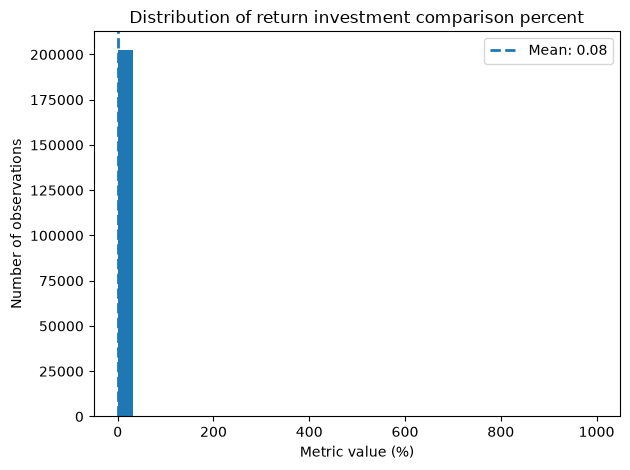

In [35]:
return_investment_hist = historical_performance["return_measurement_comparison_percent"]
# plt.figure(figsize=(10,6))
plt.hist(return_investment_hist, bins=30)
plt.axvline(
    return_investment_hist.mean(),
    linestyle = "--",
    linewidth = 2,
    label=f"Mean: {return_investment_hist.mean():.2f}")


plt.title(f"Distribution of return investment comparison percent")
plt.xlabel("Metric value (%)")
plt.ylabel("Number of observations")
plt.legend()
plt.tight_layout()
plt.show()

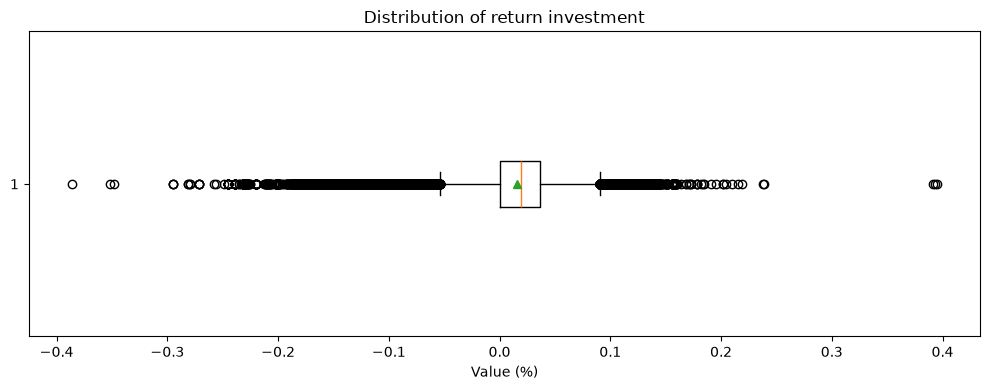

In [36]:
return_investment_hist = historical_performance[historical_performance["return_measurement_comparison_percent"] < 2]["return_measurement_comparison_percent"]
# Create boxplot
plt.figure(figsize=(10, 4))
plt.boxplot(
    return_investment_hist,
    orientation="horizontal",
    showmeans=True
)

plt.title(f"Distribution of return investment")
plt.xlabel("Value (%)")
# plt.yticks([1], [metric])
plt.tight_layout()
plt.show()

Anomaly: there is a impossibly high number (999). Need to check that

In [37]:
historical_performance[historical_performance["return_measurement_comparison_percent"] > 1]

,abn_product_identifier,abn_investment_menu_identifier,abn_investment_option_identifier,fees_and_costs_arrangement_identifier,period_end_date,product_name,product_type,product_phase,investment_menu_name,investment_menu_type,...,investment_option_category,life_cycle_name,fund_name,rse_abn,trustee_name,fund_public_offer_status,open_to_new_mems,return_measurement_comparison_percent,return_investment_five_year_volatility_comparison_percent,return_investment_ten_year_volatility_comparison_percent
136054,26382680883-LUCRFMYSUPER,26382680883-INVMYSUPER,26382680883-MYSUPERBAL,FEEMYSUPER,2022-03-31,LUCRF Super MySuper,MySuper Product,Accumulation,LUCRF Super MySuper,Generic,...,Multi Sector,NaN,Labour Union Co-Operative Retirement Fund,26382680883,NaN,Public Offer,Y,7.82,NaN,NaN
142580,26382680883-LUCRFACCUM,26382680883-INVACCUM,26382680883-ACCHGHGTH,FEEACCUM,2022-03-31,LUCRF Super Accumulation,Choice Product,Accumulation,LUCRF Super Accumulation,Generic,...,Multi Sector,NaN,Labour Union Co-Operative Retirement Fund,26382680883,NaN,Public Offer,Y,9.58,NaN,NaN
143886,26382680883-LUCRFACCUM,26382680883-INVACCUM,26382680883-ACCBAL,FEEACCUM,2022-03-31,LUCRF Super Accumulation,Choice Product,Accumulation,LUCRF Super Accumulation,Generic,...,Multi Sector,NaN,Labour Union Co-Operative Retirement Fund,26382680883,NaN,Public Offer,Y,7.82,NaN,NaN
143889,26382680883-LUCRFACCUM,26382680883-INVACCUM,26382680883-ACCCONS,FEEACCUM,2022-03-31,LUCRF Super Accumulation,Choice Product,Accumulation,LUCRF Super Accumulation,Generic,...,Multi Sector,NaN,Labour Union Co-Operative Retirement Fund,26382680883,NaN,Public Offer,Y,4.56,NaN,NaN
144948,26382680883-LUCRFACCUM,26382680883-INVACCUM,26382680883-ACCMOD,FEEACCUM,2022-03-31,LUCRF Super Accumulation,Choice Product,Accumulation,LUCRF Super Accumulation,Generic,...,Multi Sector,NaN,Labour Union Co-Operative Retirement Fund,26382680883,NaN,Public Offer,Y,6.05,NaN,NaN
145038,26382680883-LUCRFACCUM,26382680883-INVACCUM,26382680883-ACCINDBAL,FEEACCUM,2022-03-31,LUCRF Super Accumulation,Choice Product,Accumulation,LUCRF Super Accumulation,Generic,...,Multi Sector,NaN,Labour Union Co-Operative Retirement Fund,26382680883,NaN,Public Offer,Y,7.84,NaN,NaN
179812,26382680883-LUCRFPEN,26382680883-INVPEN,26382680883-PENCONS,FEEPEN,2022-03-31,LUCRF Super Pension,Choice Product,Retirement,LUCRF Super Pension,Generic,...,Multi Sector,NaN,Labour Union Co-Operative Retirement Fund,26382680883,NaN,Public Offer,Y,5.19,NaN,NaN
180166,26382680883-LUCRFPEN,26382680883-INVPEN,26382680883-PENINDBAL,FEEPEN,2022-03-31,LUCRF Super Pension,Choice Product,Retirement,LUCRF Super Pension,Generic,...,Multi Sector,NaN,Labour Union Co-Operative Retirement Fund,26382680883,NaN,Public Offer,Y,8.83,NaN,NaN
180275,26382680883-LUCRFPEN,26382680883-INVPEN,26382680883-PENBAL,FEEPEN,2022-03-31,LUCRF Super Pension,Choice Product,Retirement,LUCRF Super Pension,Generic,...,Multi Sector,NaN,Labour Union Co-Operative Retirement Fund,26382680883,NaN,Public Offer,Y,8.82,NaN,NaN
180278,26382680883-LUCRFPEN,26382680883-INVPEN,26382680883-PENMOD,FEEPEN,2022-03-31,LUCRF Super Pension,Choice Product,Retirement,LUCRF Super Pension,Generic,...,Multi Sector,NaN,Labour Union Co-Operative Retirement Fund,26382680883,NaN,Public Offer,Y,6.88,NaN,NaN


value 999 might be a placeholder to define empty or undefined value. Because of that, that number can be considered as NULL. For now, it can be changed into NULL.
Other values below 999 but still above 1 could be considered to be format error where the data should be in decimal but the value could still be in percentage. Because of that, it could be divided 100 to make it decimal.

In [38]:
# historical_performance = historical_performance.drop(columns=["return_measurement_comparison_percent_raw", "comparison_return_correction_status"])

In [39]:
# preserve original value
historical_performance["return_measurement_comparison_percent_raw"] = historical_performance["return_measurement_comparison_percent"]

In [40]:
# flag the correction
historical_performance["comparison_return_correction_status"] = pd.NA

# identify 999 error
invalid_return_number_mask = historical_performance["return_measurement_comparison_percent_raw"].eq(999)
historical_performance.loc[invalid_return_number_mask, "return_measurement_comparison_percent"] = pd.NA

# change the 999 error flag
historical_performance.loc[invalid_return_number_mask, "comparison_return_correction_status"] = "999 error"

In [41]:
# historical_performance[historical_performance["comparison_return_correction_status"] == "999 error"]

# identify scale error
scale_error_mask = historical_performance["return_measurement_comparison_percent_raw"].between(4.56, 100)

historical_performance.loc[scale_error_mask, "return_measurement_comparison_percent"] = (
    historical_performance.loc[scale_error_mask, "return_measurement_comparison_percent"]/100
)

# change the scale error flage
historical_performance.loc[scale_error_mask, "comparison_return_correction_status"] = "scale error"

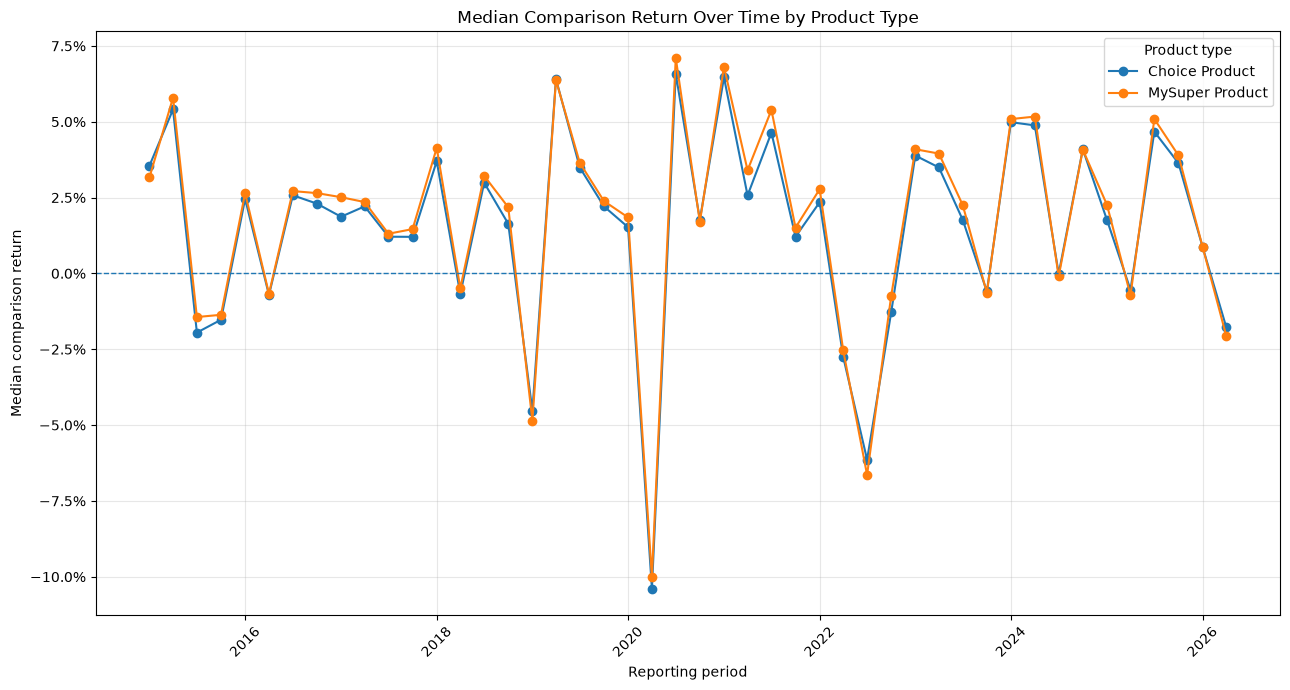

In [42]:
from matplotlib.ticker import PercentFormatter

date_col = "period_end_date"
metric = "return_measurement_comparison_percent"
group_col = "product_type"

# Remove invalid or missing records
plot_source = historical_performance.dropna(
    subset=[date_col, metric, group_col]
).copy()

# Calculate one average value per period and product type
plot_df = (
    plot_source
    .groupby(
        [date_col, group_col],
        as_index=False
    )[metric]
    .median()
    .sort_values([group_col, date_col])
)

# Create one line for each product type
plt.figure(figsize=(13, 7))

for product_type, type_df in plot_df.groupby(group_col):
    plt.plot(
        type_df[date_col],
        type_df[metric],
        marker="o",
        linewidth=1.5,
        label=product_type
    )

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Median Comparison Return Over Time by Product Type"
)
plt.xlabel("Reporting period")
plt.ylabel("Median comparison return")

# Raw values are decimals: 0.02 displays as 2%
plt.gca().yaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)

plt.legend(title="Product type")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

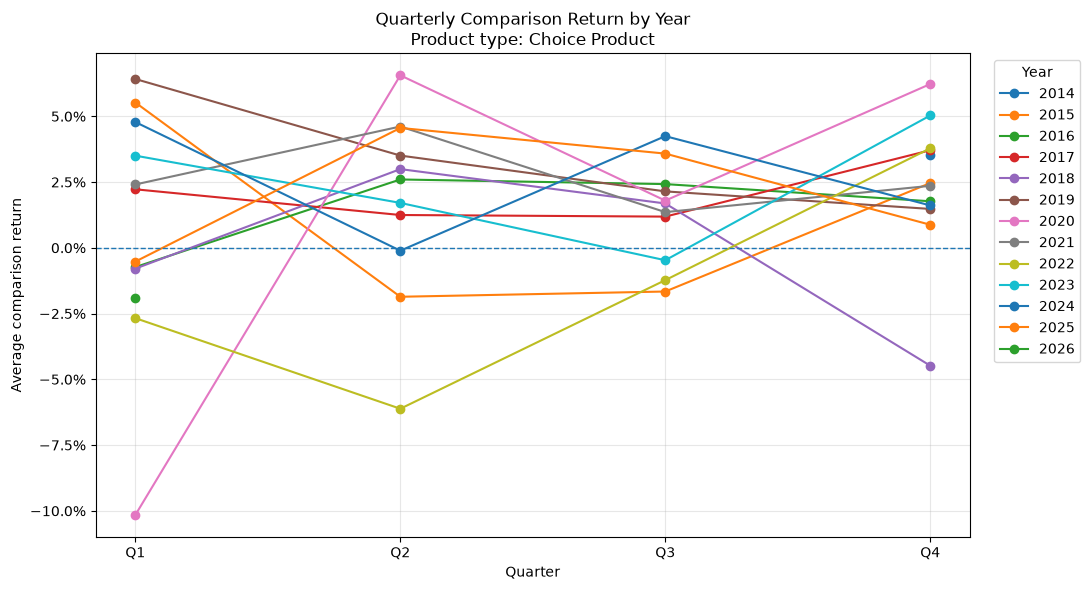

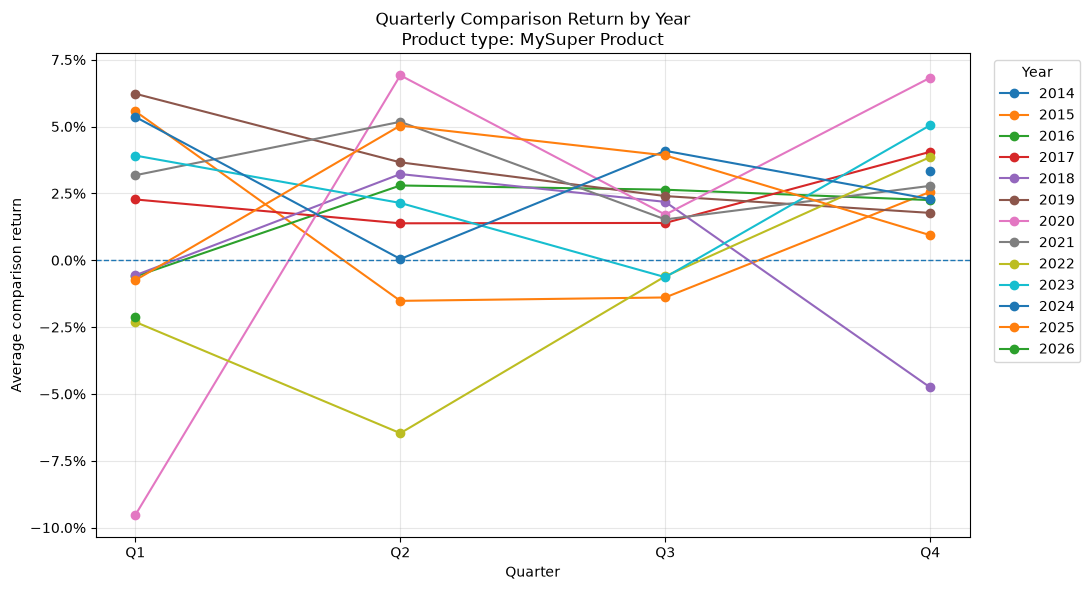

In [43]:
plot_source_yearly = plot_source.copy()


# Create year and quarter fields
plot_source_yearly["year"] = plot_source_yearly[date_col].dt.year
plot_source_yearly["quarter_num"] = plot_source_yearly[date_col].dt.quarter

# Calculate one average return for each
# product type × year × quarter
plot_df = (
    plot_source_yearly
    .groupby(
        [
            group_col,
            "year",
            "quarter_num"
        ],
        as_index=False
    )[metric]
    .mean()
    .sort_values(
        [
            group_col,
            "year",
            "quarter_num"
        ]
    )
)

# Generate one separate chart for each product type
for product_type, product_type_df in plot_df.groupby(
    group_col
):
    plt.figure(figsize=(11, 6))

    # One line for each year
    for year, year_df in product_type_df.groupby("year"):

        # Ensure the x-axis always contains Q1–Q4
        quarterly_values = (
            year_df
            .set_index("quarter_num")[metric]
            .reindex([1, 2, 3, 4])
        )

        plt.plot(
            [1, 2, 3, 4],
            quarterly_values.values,
            marker="o",
            linewidth=1.5,
            label=str(year)
        )

    plt.axhline(
        y=0,
        linestyle="--",
        linewidth=1
    )

    plt.title(
        f"Quarterly Comparison Return by Year\n"
        f"Product type: {product_type}"
    )

    plt.xlabel("Quarter")
    plt.ylabel("Average comparison return")

    plt.xticks(
        [1, 2, 3, 4],
        ["Q1", "Q2", "Q3", "Q4"]
    )

    # Raw values use decimal representation:
    # 0.02 is displayed as 2%
    plt.gca().yaxis.set_major_formatter(
        PercentFormatter(xmax=1)
    )

    plt.legend(
        title="Year",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

#### Checking 10 years volatility

##### Empty values

In [44]:
historical_performance["return_investment_ten_year_volatility_comparison_percent"].describe()

count    118217.000000
mean          0.059581
std           0.035830
min           0.000000
25%           0.034582
50%           0.061563
75%           0.081641
max           1.046051
Name: return_investment_ten_year_volatility_comparison_percent, dtype: float64

Check the empty/null values

In [45]:
empty_volatility_10years = historical_performance[historical_performance["return_investment_ten_year_volatility_comparison_percent"].isna()]
empty_volatility_10years["period_end_date"].describe()

# empty data date period
empty_volatility_earliest = empty_volatility_10years.groupby("product_name").agg(
    earliest_empty_end_date = (
        "period_end_date",
        "min"
    ),
    empty_number_records = (
        "period_end_date",
        "count"
    )
                            )


empty_volatility_latest = empty_volatility_10years.groupby(
                                "product_name"
                            )["period_end_date"].max().to_frame().reset_index()

empty_volatility_latest = empty_volatility_latest.rename(columns={"period_end_date":"latest_empty_end_date"})

# whole data date period
volatility_earliest = historical_performance.groupby("product_name").agg(
    earliest_end_date= ("period_end_date","min"),
    number_records= ("period_end_date", "count")
)

volatility_earliest = volatility_earliest.rename(columns={"period_end_date":"earliest_end_date"})

volatility_latest = historical_performance.groupby(
                                "product_name"
                            )["period_end_date"].max().to_frame().reset_index()

volatility_latest = volatility_latest.rename(columns={"period_end_date":"latest_end_date"})

# merge all
empty_volatility_date_comparison = pd.merge(empty_volatility_earliest, empty_volatility_latest, on="product_name", how="left")
empty_volatility_date_comparison = pd.merge(empty_volatility_date_comparison, volatility_earliest, on="product_name", how="left")
empty_volatility_date_comparison = pd.merge(empty_volatility_date_comparison, volatility_latest, on="product_name", how="left")

empty_volatility_date_comparison.head()

,product_name,earliest_empty_end_date,empty_number_records,latest_empty_end_date,earliest_end_date,number_records,latest_end_date
0,AMFG Superannuation Service Retirement,2025-09-30,3,2026-03-31,2025-09-30,3,2026-03-31
1,AMG Pension,2025-12-31,5,2025-12-31,2014-12-31,229,2026-03-31
2,AMG Personal,2025-12-31,7,2025-12-31,2014-12-31,220,2026-03-31
3,ANZ OneAnswer Allocated Pension,2014-12-31,469,2023-06-30,2014-12-31,1715,2023-06-30
4,ANZ OneAnswer Personal Super,2014-12-31,507,2023-06-30,2014-12-31,2240,2023-06-30


In [46]:
empty_volatility_date_comparison.count()

product_name               358
earliest_empty_end_date    358
empty_number_records       358
latest_empty_end_date      358
earliest_end_date          358
number_records             358
latest_end_date            358
dtype: int64

In [47]:
filtered_empty_comparison = empty_volatility_date_comparison.loc[
    (empty_volatility_date_comparison["earliest_empty_end_date"] == empty_volatility_date_comparison["earliest_end_date"])
    & (empty_volatility_date_comparison["latest_empty_end_date"] == empty_volatility_date_comparison["latest_end_date"])
].copy().reset_index(drop=True)

filtered_empty_comparison

,product_name,earliest_empty_end_date,empty_number_records,latest_empty_end_date,earliest_end_date,number_records,latest_end_date
0,AMFG Superannuation Service Retirement,2025-09-30,3,2026-03-31,2025-09-30,3,2026-03-31
1,ANZ OneAnswer Allocated Pension,2014-12-31,469,2023-06-30,2014-12-31,1715,2023-06-30
2,ANZ OneAnswer Personal Super,2014-12-31,507,2023-06-30,2014-12-31,2240,2023-06-30
3,ANZ Smart Choice Pension,2014-12-31,159,2026-03-31,2014-12-31,273,2026-03-31
4,ANZ Smart Choice Super,2014-12-31,249,2026-03-31,2014-12-31,467,2026-03-31
...,...,...,...,...,...,...,...
204,smartMonday DIRECT - Choice,2014-12-31,1505,2024-03-31,2014-12-31,1505,2024-03-31
205,smartMonday PENSION - RP,2014-12-31,425,2026-03-31,2014-12-31,425,2026-03-31
206,smartMonday PENSION - TAP,2025-06-30,12,2026-03-31,2025-06-30,12,2026-03-31
207,smartMonday PRIME - Choice,2014-12-31,2046,2026-03-31,2014-12-31,2046,2026-03-31


In [48]:
filtered_empty_comparison = empty_volatility_date_comparison.loc[
    (empty_volatility_date_comparison["empty_number_records"] == empty_volatility_date_comparison["number_records"])
].copy().reset_index(drop=True)

filtered_empty_comparison

,product_name,earliest_empty_end_date,empty_number_records,latest_empty_end_date,earliest_end_date,number_records,latest_end_date
0,AMFG Superannuation Service Retirement,2025-09-30,3,2026-03-31,2025-09-30,3,2026-03-31
1,Accelerator Personal Superannuation Plan,2014-12-31,138,2026-03-31,2014-12-31,138,2026-03-31
2,Accumulation - Choice,2014-12-31,442,2026-03-31,2014-12-31,442,2026-03-31
3,Accumulation - MySuper,2021-06-30,24,2026-03-31,2021-06-30,24,2026-03-31
4,Active Super Choice,2025-03-31,20,2026-03-31,2025-03-31,20,2026-03-31
...,...,...,...,...,...,...,...
80,smartMonday DIRECT - Choice,2014-12-31,1505,2024-03-31,2014-12-31,1505,2024-03-31
81,smartMonday PENSION - RP,2014-12-31,425,2026-03-31,2014-12-31,425,2026-03-31
82,smartMonday PENSION - TAP,2025-06-30,12,2026-03-31,2025-06-30,12,2026-03-31
83,smartMonday PRIME - Choice,2014-12-31,2046,2026-03-31,2014-12-31,2046,2026-03-31


In [49]:
hist = historical_performance.copy()
structure = structure_1b_clean.copy()

structure = structure.loc[
    ~structure["is_completely_blank"]
].copy()

structure = structure.rename(
    columns={
        "product_identifier":
            "abn_product_identifier",

        "investment_menu_identifier":
            "abn_investment_menu_identifier",

        "investment_option_identifier":
            "abn_investment_option_identifier",
    }
)

join_keys = [
    "rse_abn",
    "abn_product_identifier",
    "abn_investment_menu_identifier",
    "abn_investment_option_identifier",
]

In [50]:

# standardise identifiers
def clean_identifier(series):
    return (
        series
        .astype("string")
        .str.strip()
        .str.upper()
        .replace(
            {
                "": pd.NA,
                "NAN": pd.NA,
                "NONE": pd.NA,
            }
        )
    )


identifier_columns = [
    "abn_product_identifier",
    "abn_investment_menu_identifier",
    "abn_investment_option_identifier",
]

for col in identifier_columns:
    hist[col] = clean_identifier(hist[col])
    structure[col] = clean_identifier(structure[col])


# standardise abn number
def clean_abn(series):
    return (
        pd.to_numeric(series, errors="coerce")
        .astype("Int64")
        .astype("string")
        .str.zfill(11)
    )


hist["rse_abn"] = clean_abn(hist["rse_abn"])
structure["rse_abn"] = clean_abn(structure["rse_abn"])

# convert dates
hist["period_end_date"] = pd.to_datetime(
    hist["period_end_date"],
    format="%Y-%m-%d",
    errors="coerce"
)

structure_date_columns = [
    "period",
    "superannuation_product_inception_date",
    "investment_menu_inception_date",
    "investment_option_inception_date",
]

for col in structure_date_columns:
    structure[col] = pd.to_datetime(
        structure[col],
        format="%Y-%m-%d",
        errors="coerce"
    )

structure["period"].value_counts(dropna=False)

period
2026-03-31    130288
Name: count, dtype: int64

In [51]:
# check if the structure rows repeat by pathway
structure_grain_check = (
    structure
    .groupby(
        join_keys,
        dropna=False,
        as_index=False
    )
    .agg(
        structure_rows=(
            "pathway_identifier",
            "size"
        ),
        pathway_count=(
            "pathway_identifier",
            "nunique"
        ),
    )
    .sort_values(
        "structure_rows",
        ascending=False
    )
)

structure_grain_check.head(20)

,rse_abn,abn_product_identifier,abn_investment_menu_identifier,abn_investment_option_identifier,structure_rows,pathway_count
0,12007600799,12007600799-UNSUSF001,12007600799-UNSDEFBE,12007600799-UNSWSTRATEGY,1,1
1,16457520308,16457520308-MINEACCUMCHOICE,16457520308-ACCUMCHOICE,16457520308-CIA1C1,1,1
2,16457520308,16457520308-MINEACCUMCHOICE,16457520308-ACCUMCHOICE,16457520308-CIC1C1,1,1
3,16457520308,16457520308-MINEACCUMCHOICE,16457520308-ACCUMCHOICE,16457520308-CIE1C1,1,1
4,16457520308,16457520308-MINEACCUMCHOICE,16457520308-ACCUMCHOICE,16457520308-CIF1C1,1,1
5,16457520308,16457520308-MINEACCUMCHOICE,16457520308-ACCUMCHOICE,16457520308-CIG1C1,1,1
6,16457520308,16457520308-MINEACCUMCHOICE,16457520308-ACCUMCHOICE,16457520308-CII1C1,1,1
7,16457520308,16457520308-MINEACCUMCHOICE,16457520308-ACCUMCHOICE,16457520308-CIP1C1,1,1
8,16457520308,16457520308-MINEACCUMCHOICE,16457520308-ACCUMCHOICE,16457520308-CIS1C1,1,1
9,16457520308,16457520308-MINEACCUMCHOICE,16457520308-ACCUMCHOICE,16457520308-CIU1C1,1,1


In [52]:
# check inception-date consistency
structure_check = (
    structure
    .groupby(
        join_keys,
        dropna=False,
        as_index=False
    )
    .agg(
        structure_rows=(
            "pathway_identifier",
            "size"
        ),
        pathway_count=(
            "pathway_identifier",
            "nunique"
        ),

        product_name_count=(
            "superannuation_product_name",
            "nunique"
        ),
        product_name=(
            "superannuation_product_name",
            "first"
        ),

        product_inception_min=(
            "superannuation_product_inception_date",
            "min"
        ),
        product_inception_max=(
            "superannuation_product_inception_date",
            "max"
        ),
        product_inception_count=(
            "superannuation_product_inception_date",
            "nunique"
        ),

        menu_inception_min=(
            "investment_menu_inception_date",
            "min"
        ),
        menu_inception_max=(
            "investment_menu_inception_date",
            "max"
        ),
        menu_inception_count=(
            "investment_menu_inception_date",
            "nunique"
        ),

        option_inception_min=(
            "investment_option_inception_date",
            "min"
        ),
        option_inception_max=(
            "investment_option_inception_date",
            "max"
        ),
        option_inception_count=(
            "investment_option_inception_date",
            "nunique"
        ),

        structure_product_type=(
            "superannuation_product_type",
            "first"
        ),
        structure_menu_type=(
            "investment_menu_type",
            "first"
        ),
        structure_option_type=(
            "investment_option_type",
            "first"
        ),
        structure_option_category=(
            "investment_option_category_type",
            "first"
        ),
    )
)

# create a conflict flag
structure_check["structure_conflict"] = (
    structure_check[
        [
            "product_name_count",
            "product_inception_count",
            "menu_inception_count",
            "option_inception_count",
        ]
    ]
    .gt(1)
    .any(axis=1)
)

# inspect the conflict
structure_conflicts = structure_check.loc[
    structure_check["structure_conflict"]
].copy()

print("Conflicting investment options:", len(structure_conflicts))
structure_conflicts.head(20)

Conflicting investment options: 0


,rse_abn,abn_product_identifier,abn_investment_menu_identifier,abn_investment_option_identifier,structure_rows,pathway_count,product_name_count,product_name,product_inception_min,product_inception_max,...,menu_inception_max,menu_inception_count,option_inception_min,option_inception_max,option_inception_count,structure_product_type,structure_menu_type,structure_option_type,structure_option_category,structure_conflict


In [53]:
structure_lookup = structure_check.copy()

structure_lookup[
    "structure_product_inception_date"
] = structure_lookup["product_inception_min"].where(
    structure_lookup["product_inception_count"].eq(1)
)

structure_lookup[
    "structure_menu_inception_date"
] = structure_lookup["menu_inception_min"].where(
    structure_lookup["menu_inception_count"].eq(1)
)

structure_lookup[
    "structure_option_inception_date"
] = structure_lookup["option_inception_min"].where(
    structure_lookup["option_inception_count"].eq(1)
)

# define columns for merging
structure_lookup = structure_lookup[
    join_keys
    + [
        "product_name",
        "structure_product_type",
        "structure_menu_type",
        "structure_option_type",
        "structure_option_category",
        "structure_product_inception_date",
        "structure_menu_inception_date",
        "structure_option_inception_date",
        "structure_rows",
        "pathway_count",
        "structure_conflict",
    ]
].rename(
    columns={
        "product_name": "structure_product_name"
    }
)

assert not structure_lookup.duplicated(
    subset=join_keys
).any()

In [54]:
# merge structure to historical performance
hist_enriched = hist.merge(
    structure_lookup,
    on=join_keys,
    how="left",
    validate="many_to_one",
    indicator="_structure_merge"
)

hist_enriched["structure_matched"] = (
    hist_enriched["_structure_merge"].eq("both")
)

# measure match coverage
row_match_summary = (
    hist_enriched["_structure_merge"]
    .value_counts(dropna=False)
    .rename_axis("merge_status")
    .reset_index(name="number_rows")
)

row_match_summary["percentage"] = (
    row_match_summary["number_rows"]
    / len(hist_enriched)
    * 100
)

row_match_summary

,merge_status,number_rows,percentage
0,left_only,107679,53.131785
1,both,94985,46.868215
2,right_only,0,0.000000


In [55]:
# unique option match
option_match_summary = (
    hist_enriched[
        join_keys + ["structure_matched"]
    ]
    .drop_duplicates(subset=join_keys)
    .groupby(
        "structure_matched",
        as_index=False
    )
    .size()
    .rename(columns={"size": "unique_options"})
)

option_match_summary

,structure_matched,unique_options
0,False,3715
1,True,2660


In [56]:
match_by_period = (
    hist_enriched
    .groupby(
        "period_end_date",
        as_index=False
    )
    .agg(
        total_rows=(
            "structure_matched",
            "size"
        ),
        matched_rows=(
            "structure_matched",
            "sum"
        ),
    )
)

match_by_period["match_percentage"] = (
    match_by_period["matched_rows"]
    / match_by_period["total_rows"]
    * 100
)

match_by_period.sort_values("period_end_date")

,period_end_date,total_rows,matched_rows,match_percentage
0,2014-12-31,4287,1670,38.954980
1,2015-03-31,4309,1679,38.964957
2,2015-06-30,4348,1690,38.868445
3,2015-09-30,4355,1692,38.851894
4,2015-12-31,4357,1694,38.879963
5,2016-03-31,4395,1695,38.566553
6,2016-06-30,4507,1712,37.985356
7,2016-09-30,4526,1719,37.980557
8,2016-12-31,4685,1783,38.057631
9,2017-03-31,4699,1792,38.135774


In [57]:
historical_option_summary = (
    hist
    .groupby(
        join_keys,
        dropna=False,
        as_index=False
    )
    .agg(
        first_historical_period=(
            "period_end_date",
            "min"
        ),
        last_historical_period=(
            "period_end_date",
            "max"
        ),
        historical_record_count=(
            "period_end_date",
            "size"
        ),
    )
)

# merge it
hist_enriched = hist_enriched.merge(
    historical_option_summary,
    on=join_keys,
    how="left",
    validate="many_to_one"
)

In [58]:
# Calculate when ten years of observed APRA history has accumulated
hist_enriched[
    "historical_ten_year_anniversary"
] = (
    hist_enriched["first_historical_period"]
    + pd.DateOffset(years=10)
)

hist_enriched[
    "has_ten_years_observed_history"
] = (
    hist_enriched["period_end_date"]
    >= hist_enriched[
        "historical_ten_year_anniversary"
    ]
)

# Calculate option age where the structure match is reliable
hist_enriched["option_age_days"] = (
    hist_enriched["period_end_date"]
    - hist_enriched[
        "structure_option_inception_date"
    ]
).dt.days

hist_enriched["negative_option_age"] = (
    hist_enriched["option_age_days"] < 0
)

# Create the ten-year anniversary
hist_enriched[
    "option_ten_year_anniversary"
] = (
    hist_enriched[
        "structure_option_inception_date"
    ]
    + pd.DateOffset(years=10)
)

hist_enriched["valid_option_age"] = (
    hist_enriched["structure_matched"]
    & ~hist_enriched["structure_conflict"].fillna(False)
    & hist_enriched[
        "structure_option_inception_date"
    ].notna()
    & ~hist_enriched["negative_option_age"].fillna(False)
)

hist_enriched["eligible_10y_by_inception"] = pd.Series(
    pd.NA,
    index=hist_enriched.index,
    dtype="boolean"
)

valid_age_mask = hist_enriched["valid_option_age"]

hist_enriched.loc[
    valid_age_mask,
    "eligible_10y_by_inception"
] = (
    hist_enriched.loc[
        valid_age_mask,
        "period_end_date"
    ]
    >= hist_enriched.loc[
        valid_age_mask,
        "option_ten_year_anniversary"
    ]
)

In [59]:
metric_10y = (
    "return_investment_ten_year_"
    "volatility_comparison_percent"
)

metric_5y = (
    "return_investment_five_year_"
    "volatility_comparison_percent"
)

hist_enriched[metric_10y] = pd.to_numeric(
    hist_enriched[metric_10y],
    errors="coerce"
)

hist_enriched[metric_5y] = pd.to_numeric(
    hist_enriched[metric_5y],
    errors="coerce"
)

# Create the status variables
has_10y = hist_enriched[metric_10y].notna()
has_5y = hist_enriched[metric_5y].notna()

matched = hist_enriched["structure_matched"]

conflict = (
    hist_enriched["structure_conflict"]
    .fillna(False)
)

inception_missing = (
    hist_enriched[
        "structure_option_inception_date"
    ].isna()
)

negative_age = (
    hist_enriched["negative_option_age"]
    .fillna(False)
)

eligible_10y = (
    hist_enriched["eligible_10y_by_inception"]
    .fillna(False)
)

has_10y_history = (
    hist_enriched[
        "has_ten_years_observed_history"
    ]
)

# classify each record
hist_enriched["volatility_10y_status"] = np.select(
    [
        has_10y,

        ~has_10y
        & matched
        & conflict,

        ~has_10y
        & matched
        & ~conflict
        & inception_missing,

        ~has_10y
        & matched
        & negative_age,

        ~has_10y
        & hist_enriched["valid_option_age"]
        & ~eligible_10y,

        ~has_10y
        & hist_enriched["valid_option_age"]
        & eligible_10y
        & has_5y,

        ~has_10y
        & hist_enriched["valid_option_age"]
        & eligible_10y
        & ~has_5y,

        ~has_10y
        & ~matched
        & ~has_10y_history,

        ~has_10y
        & ~matched
        & has_10y_history
        & has_5y,

        ~has_10y
        & ~matched
        & has_10y_history
        & ~has_5y,
    ],
    [
        "observed_10y",

        "review_structure_conflict",

        "matched_but_inception_missing",

        "review_negative_option_age",

        "expected_missing_under_10_years",

        "eligible_missing_10y_5y_available",

        "eligible_missing_both_5y_and_10y",

        "unmatched_less_than_10y_observed_history",

        "unmatched_10y_history_5y_available",

        "unmatched_10y_history_both_missing",
    ],
    default="review_unclassified"
)

In [60]:
# record-level summary
status_summary = (
    hist_enriched
    .groupby(
        "volatility_10y_status",
        as_index=False
    )
    .size()
    .rename(columns={"size": "number_rows"})
)

status_summary["percentage"] = (
    status_summary["number_rows"]
    / len(hist_enriched)
    * 100
)

status_summary.sort_values(
    "number_rows",
    ascending=False
)

,volatility_10y_status,number_rows,percentage
3,observed_10y,118217,58.331524
5,unmatched_less_than_10y_observed_history,41033,20.246812
2,expected_missing_under_10_years,39753,19.615225
1,eligible_missing_both_5y_and_10y,3175,1.566632
0,eligible_missing_10y_5y_available,461,0.227470
4,review_negative_option_age,25,0.012336


In [61]:
# option level summary
option_status_summary = (
    hist_enriched[
        ["volatility_10y_status"] + join_keys
    ]
    .drop_duplicates()
    .groupby(
        "volatility_10y_status",
        as_index=False
    )
    .size()
    .rename(columns={"size": "unique_options"})
)

option_status_summary.sort_values(
    "unique_options",
    ascending=False
)

,volatility_10y_status,unique_options
3,observed_10y,4486
5,unmatched_less_than_10y_observed_history,2444
2,expected_missing_under_10_years,1720
1,eligible_missing_both_5y_and_10y,219
0,eligible_missing_10y_5y_available,124
4,review_negative_option_age,21


In [62]:
product_keys = [
    "rse_abn",
    "abn_product_identifier",
    "product_name",
]

product_diagnosis = (
    hist_enriched
    .groupby(
        product_keys,
        dropna=False,
        as_index=False
    )
    .agg(
        total_rows=(
            metric_10y,
            "size"
        ),
        observed_10y_rows=(
            metric_10y,
            "count"
        ),
        matched_structure_rows=(
            "structure_matched",
            "sum"
        ),
        earliest_period=(
            "period_end_date",
            "min"
        ),
        latest_period=(
            "period_end_date",
            "max"
        ),
        expected_under_10y_rows=(
            "volatility_10y_status",
            lambda x: x.eq(
                "expected_missing_under_10_years"
            ).sum()
        ),
        eligible_missing_rows=(
            "volatility_10y_status",
            lambda x: x.isin(
                [
                    "eligible_missing_10y_5y_available",
                    "eligible_missing_both_5y_and_10y",
                ]
            ).sum()
        ),
        unmatched_rows=(
            "structure_matched",
            lambda x: (~x).sum()
        ),
    )
)

product_diagnosis["missing_10y_rows"] = (
    product_diagnosis["total_rows"]
    - product_diagnosis["observed_10y_rows"]
)

product_diagnosis["missing_10y_percentage"] = (
    product_diagnosis["missing_10y_rows"]
    / product_diagnosis["total_rows"]
    * 100
)

product_diagnosis["all_10y_missing"] = (
    product_diagnosis["observed_10y_rows"].eq(0)
)

all_missing_products = (
    product_diagnosis.loc[
        product_diagnosis["all_10y_missing"]
    ]
    .sort_values(
        [
            "eligible_missing_rows",
            "unmatched_rows",
            "total_rows",
        ],
        ascending=False
    )
)

all_missing_products

,rse_abn,abn_product_identifier,product_name,total_rows,observed_10y_rows,matched_structure_rows,earliest_period,latest_period,expected_under_10y_rows,eligible_missing_rows,unmatched_rows,missing_10y_rows,missing_10y_percentage,all_10y_missing
359,68964712340,68964712340-68964712340001CHOICE,smartMonday PRIME - Choice,2046,0,849,2014-12-31,2026-03-31,250,599,1197,2046,100.0,True
360,68964712340,68964712340-68964712340001MYSUP,smartMonday PRIME - MySuper,1631,0,615,2014-12-31,2026-03-31,246,369,1016,1631,100.0,True
442,76746741299,76746741299-NMRACC121,RLA Personal Super Plan,322,0,322,2014-12-31,2026-03-31,0,322,0,322,100.0,True
362,68964712340,68964712340-68964712340010RP,smartMonday PENSION - RP,425,0,230,2014-12-31,2026-03-31,45,185,195,425,100.0,True
438,76746741299,76746741299-NMRACC117,Provider Personal Retirement Plan,184,0,184,2014-12-31,2026-03-31,0,184,0,184,100.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
364,68964712340,68964712340-68964712340018VERVE,Verve Super,20,0,20,2025-06-30,2026-03-31,20,0,0,20,100.0,True
76,24496637884,24496637884-24496637884287,Active Super Lifestage Product,15,0,15,2025-03-31,2026-03-31,15,0,0,15,100.0,True
277,57929339093,57929339093-APSPENSION,AMFG Superannuation Service Retirement,3,0,3,2025-09-30,2026-03-31,3,0,0,3,100.0,True
525,92381911598,92381911598-BDAMPNORTHAPG,MyNorth Pension - GROW,2,0,2,2025-12-31,2026-03-31,2,0,0,2,100.0,True


In [63]:
# add missingness indicator
hist_enriched["volatility_10y_missing"] = (
    hist_enriched[metric_10y]
    .isna()
    .astype("int8")
)

hist_enriched["volatility_5y_missing"] = (
    hist_enriched[metric_5y]
    .isna()
    .astype("int8")
)

hist_enriched["structure_unmatched"] = (
    ~hist_enriched["structure_matched"]
).astype("int8")

##### Trend

In [66]:
hist_enriched["return_investment_ten_year_volatility_comparison_percent"].describe()

count    118217.000000
mean          0.059581
std           0.035830
min           0.000000
25%           0.034582
50%           0.061563
75%           0.081641
max           1.046051
Name: return_investment_ten_year_volatility_comparison_percent, dtype: float64

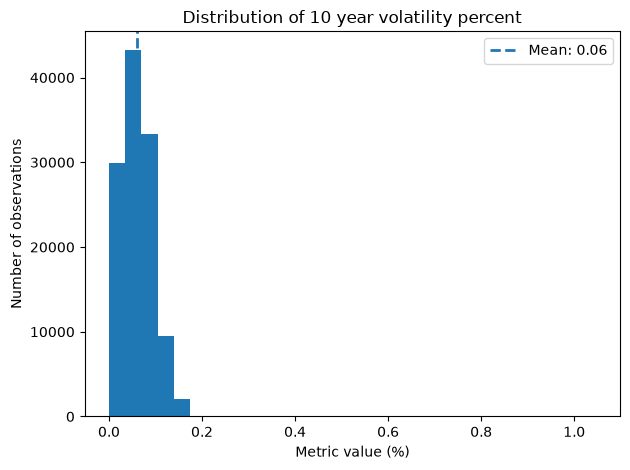

In [74]:
hist_volatile10 = hist_enriched["return_investment_ten_year_volatility_comparison_percent"]
# plt.figure(figsize=(10,6))
plt.hist(hist_volatile10, bins=30)
plt.axvline(
    hist_volatile10.mean(),
    linestyle = "--",
    linewidth = 2,
    label=f"Mean: {hist_volatile10.mean():.2f}")


plt.title(f"Distribution of 10 year volatility percent")
plt.xlabel("Metric value (%)")
plt.ylabel("Number of observations")
plt.legend()
plt.tight_layout()
plt.show()

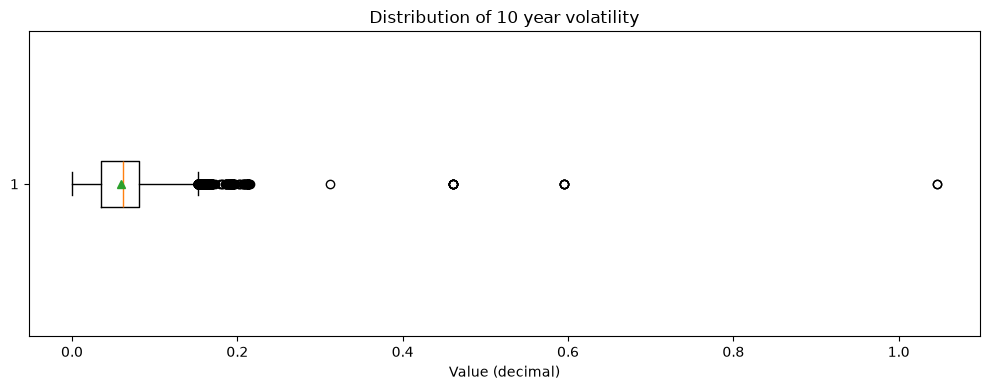

In [87]:
hist_volatile10 = hist_enriched["return_investment_ten_year_volatility_comparison_percent"].replace([np.inf, -np.inf], np.nan).dropna()

# Create boxplot
plt.figure(figsize=(10, 4))
plt.boxplot(
    hist_volatile10,
    orientation="horizontal",
    showmeans=True
)

plt.title(f"Distribution of 10 year volatility")
plt.xlabel("Value (decimal)")
# plt.yticks([1], [metric])
plt.tight_layout()
plt.show()

In [89]:
# check volatility above 0.3
metric_10y = (
    "return_investment_ten_year_"
    "volatility_comparison_percent"
)


high_volatility = (
    hist_enriched.loc[
        hist_enriched[metric_10y].gt(0.30),
        [
            "rse_abn",
            "abn_product_identifier",
            "abn_investment_menu_identifier",
            "abn_investment_option_identifier",
            "fees_and_costs_arrangement_identifier",
            "period_end_date",
            "product_name",
            "product_type",
            "investment_menu_name",
            "investment_menu_type",
            "investment_option_name",
            "investment_option_type",
            "investment_option_category",
            metric_10y,
        ],
    ]
    .sort_values(
        [
            "abn_investment_option_identifier",
            "period_end_date",
        ]
    )
)

# make it in percentage
high_volatility = high_volatility.assign(
     volatility_10y_pct=high_volatility[metric_10y] * 100,
)

high_volatility[
    [
        "period_end_date",
        "product_name",
        "investment_option_name",
        "investment_option_category",
        "volatility_10y_pct",
    ]
]

,period_end_date,product_name,investment_option_name,investment_option_category,volatility_10y_pct
127039,2014-12-31,AMG Pension,AMG Conservative,Multi Sector,46.1000
127040,2015-03-31,AMG Pension,AMG Conservative,Multi Sector,46.1000
127041,2015-06-30,AMG Pension,AMG Conservative,Multi Sector,46.1000
127042,2015-09-30,AMG Pension,AMG Conservative,Multi Sector,46.0500
127043,2015-12-31,AMG Pension,AMG Conservative,Multi Sector,46.1000
127044,2016-03-31,AMG Pension,AMG Conservative,Multi Sector,46.0500
127045,2016-06-30,AMG Pension,AMG Conservative,Multi Sector,46.0500
127046,2016-09-30,AMG Pension,AMG Conservative,Multi Sector,46.0500
167102,2024-03-31,Superhero Super Accumulation,High Growth (Accumulation),Multi Sector,31.2584
171458,2022-09-30,RetireSelect Complete Super Accumulation,High Growth Option Pen,Multi Sector,59.5015


In [91]:
option_keys = [
    "rse_abn",
    "abn_product_identifier",
    "abn_investment_menu_identifier",
    "abn_investment_option_identifier",
]

unique_high_volatility = (
    high_volatility[
        option_keys
        + [
            "period_end_date",
            "product_name",
            "investment_option_name",
            metric_10y,
        ]
    ]
    .drop_duplicates(
        subset=option_keys + ["period_end_date"]
    )
)

print("High-volatility rows:", len(high_volatility))
print(
    "Unique option-period observations:",
    len(unique_high_volatility)
)
print(
    "Unique affected investment options:",
    unique_high_volatility[
        option_keys
    ].drop_duplicates().shape[0]
)

High-volatility rows: 16
Unique option-period observations: 16
Unique affected investment options: 5


This shows that these high values only happened in only 5 unique investment options, moreover, for certain options, the high value anomalies happened across different periods.

In [92]:
affected_options = (
    high_volatility[option_keys]
    .drop_duplicates()
)

affected_history = (
    hist_enriched.merge(
        affected_options,
        on=option_keys,
        how="inner",
        validate="many_to_many",
    )
    [
        option_keys
        + [
            "period_end_date",
            "product_name",
            "investment_option_name",
            "investment_option_category",
            metric_10y,
        ]
    ]
    .drop_duplicates(
        subset=option_keys + ["period_end_date"]
    )
    .sort_values(
        option_keys + ["period_end_date"]
    )
)

affected_history

,rse_abn,abn_product_identifier,abn_investment_menu_identifier,abn_investment_option_identifier,period_end_date,product_name,investment_option_name,investment_option_category,return_investment_ten_year_volatility_comparison_percent
47,30099320583,30099320583-AMGPPE001,30099320583-AMGMULTI,30099320583-AMGCONSE,2014-12-31,AMG Pension,AMG Conservative,Multi Sector,0.461000
48,30099320583,30099320583-AMGPPE001,30099320583-AMGMULTI,30099320583-AMGCONSE,2015-03-31,AMG Pension,AMG Conservative,Multi Sector,0.461000
49,30099320583,30099320583-AMGPPE001,30099320583-AMGMULTI,30099320583-AMGCONSE,2015-06-30,AMG Pension,AMG Conservative,Multi Sector,0.461000
50,30099320583,30099320583-AMGPPE001,30099320583-AMGMULTI,30099320583-AMGCONSE,2015-09-30,AMG Pension,AMG Conservative,Multi Sector,0.460500
51,30099320583,30099320583-AMGPPE001,30099320583-AMGMULTI,30099320583-AMGCONSE,2015-12-31,AMG Pension,AMG Conservative,Multi Sector,0.461000
...,...,...,...,...,...,...,...,...,...
97,43905581638,43905581638-YOURCHOICEACCUM,43905581638-YOURCHOICEACCUM,43905581638-OVPSHGHGRWTH,2023-03-31,YourChoice Complete Super Accumulation,High Growth Option Pen,Multi Sector,0.084040
98,43905581638,43905581638-YOURCHOICEACCUM,43905581638-YOURCHOICEACCUM,43905581638-OVPSHGHGRWTH,2023-06-30,YourChoice Complete Super Accumulation,High Growth Option Pen,Multi Sector,0.083622
99,43905581638,43905581638-YOURCHOICEACCUM,43905581638-YOURCHOICEACCUM,43905581638-OVPSHGHGRWTH,2023-09-30,YourChoice Complete Super Accumulation,High Growth Option Pen,Multi Sector,0.083622
100,43905581638,43905581638-YOURCHOICEACCUM,43905581638-YOURCHOICEACCUM,43905581638-OVPSHGHGRWTH,2023-12-31,YourChoice Complete Super Accumulation,High Growth Option Pen,Multi Sector,1.046051


In [94]:
option_period_volatility = (
    hist_enriched
    .groupby(
        option_keys + ["period_end_date"],
        as_index=False,
        dropna=False,
    )
    .agg(
        product_name=("product_name", "first"),
        investment_option_name=(
            "investment_option_name",
            "first",
        ),
        investment_option_category=(
            "investment_option_category",
            "first",
        ),
        volatility_10y=(metric_10y, "median"),
        source_row_count=(metric_10y, "size"),
        unique_10y_values=(metric_10y, "nunique"),
    )
    .sort_values(
        option_keys + ["period_end_date"]
    )
)

grouped = option_period_volatility.groupby(
    option_keys,
    dropna=False,
)

option_period_volatility["previous_10y"] = (
    grouped["volatility_10y"].shift(1)
)

option_period_volatility["next_10y"] = (
    grouped["volatility_10y"].shift(-1)
)

option_period_volatility["neighbour_median"] = (
    option_period_volatility[
        ["previous_10y", "next_10y"]
    ]
    .median(axis=1)
)

option_period_volatility["ratio_to_neighbours"] = (
    option_period_volatility["volatility_10y"]
    / option_period_volatility["neighbour_median"]
)

high_value_diagnosis = (
    option_period_volatility.loc[
        option_period_volatility[
            "volatility_10y"
        ].gt(0.30)
    ]
    [
        option_keys
        + [
            "period_end_date",
            "product_name",
            "investment_option_name",
            "investment_option_category",
            "previous_10y",
            "volatility_10y",
            "next_10y",
            "neighbour_median",
            "ratio_to_neighbours",
            "source_row_count",
            "unique_10y_values",
        ]
    ]
)

high_value_diagnosis

,rse_abn,abn_product_identifier,abn_investment_menu_identifier,abn_investment_option_identifier,period_end_date,product_name,investment_option_name,investment_option_category,previous_10y,volatility_10y,next_10y,neighbour_median,ratio_to_neighbours,source_row_count,unique_10y_values
19829,30099320583,30099320583-AMGPPE001,30099320583-AMGMULTI,30099320583-AMGCONSE,2014-12-31,AMG Pension,AMG Conservative,Multi Sector,NaN,0.461000,0.461000,0.461000,1.000000,1,1
19830,30099320583,30099320583-AMGPPE001,30099320583-AMGMULTI,30099320583-AMGCONSE,2015-03-31,AMG Pension,AMG Conservative,Multi Sector,0.461000,0.461000,0.461000,0.461000,1.000000,1,1
19831,30099320583,30099320583-AMGPPE001,30099320583-AMGMULTI,30099320583-AMGCONSE,2015-06-30,AMG Pension,AMG Conservative,Multi Sector,0.461000,0.461000,0.460500,0.460750,1.000543,1,1
19832,30099320583,30099320583-AMGPPE001,30099320583-AMGMULTI,30099320583-AMGCONSE,2015-09-30,AMG Pension,AMG Conservative,Multi Sector,0.461000,0.460500,0.461000,0.461000,0.998915,1,1
19833,30099320583,30099320583-AMGPPE001,30099320583-AMGMULTI,30099320583-AMGCONSE,2015-12-31,AMG Pension,AMG Conservative,Multi Sector,0.460500,0.461000,0.460500,0.460500,1.001086,1,1
19834,30099320583,30099320583-AMGPPE001,30099320583-AMGMULTI,30099320583-AMGCONSE,2016-03-31,AMG Pension,AMG Conservative,Multi Sector,0.461000,0.460500,0.460500,0.460750,0.999457,1,1
19835,30099320583,30099320583-AMGPPE001,30099320583-AMGMULTI,30099320583-AMGCONSE,2016-06-30,AMG Pension,AMG Conservative,Multi Sector,0.460500,0.460500,0.460500,0.460500,1.000000,1,1
19836,30099320583,30099320583-AMGPPE001,30099320583-AMGMULTI,30099320583-AMGCONSE,2016-09-30,AMG Pension,AMG Conservative,Multi Sector,0.460500,0.460500,0.011400,0.235950,1.951685,1,1
44897,43905581638,43905581638-AUSPRACACCUM,43905581638-AUSPRACACCUM,43905581638-OVPSHGHGRWTH,2022-12-31,Australian Practical Superannuation Accumulation,High Growth Option Pen,Multi Sector,NaN,0.595013,0.084040,0.084040,7.080117,1,1
45293,43905581638,43905581638-HEROACCUM,43905581638-HEROMAINCHOICE,43905581638-LAMSHGHGRWTH,2024-03-31,Superhero Super Accumulation,High Growth (Accumulation),Multi Sector,0.078655,0.312584,0.112093,0.095374,3.277455,1,1


Number of affected investment options: 5
Option-periods with conflicting volatility values: 0


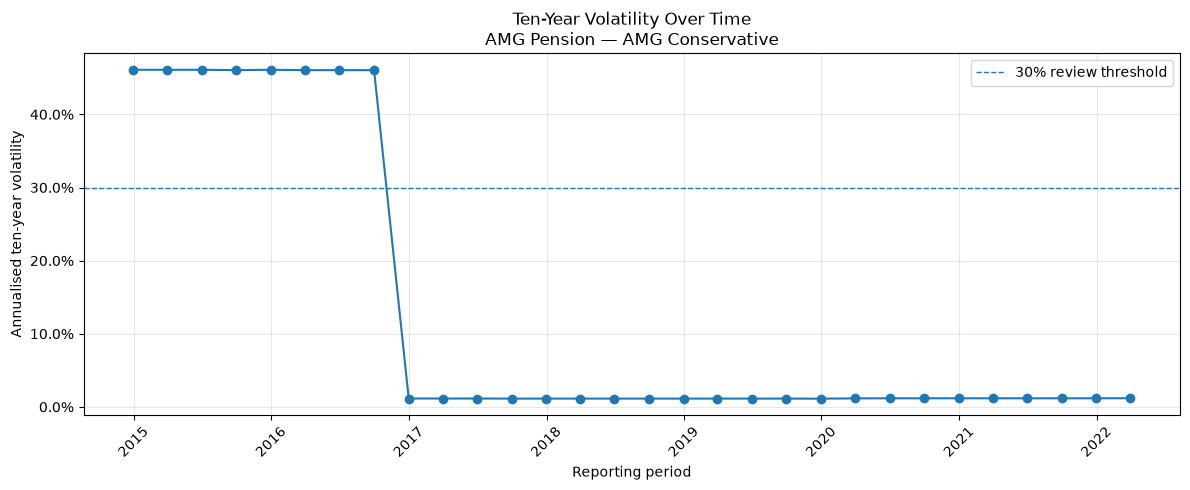

Option identifier: 30099320583-AMGCONSE
Maximum volatility: 46.10%



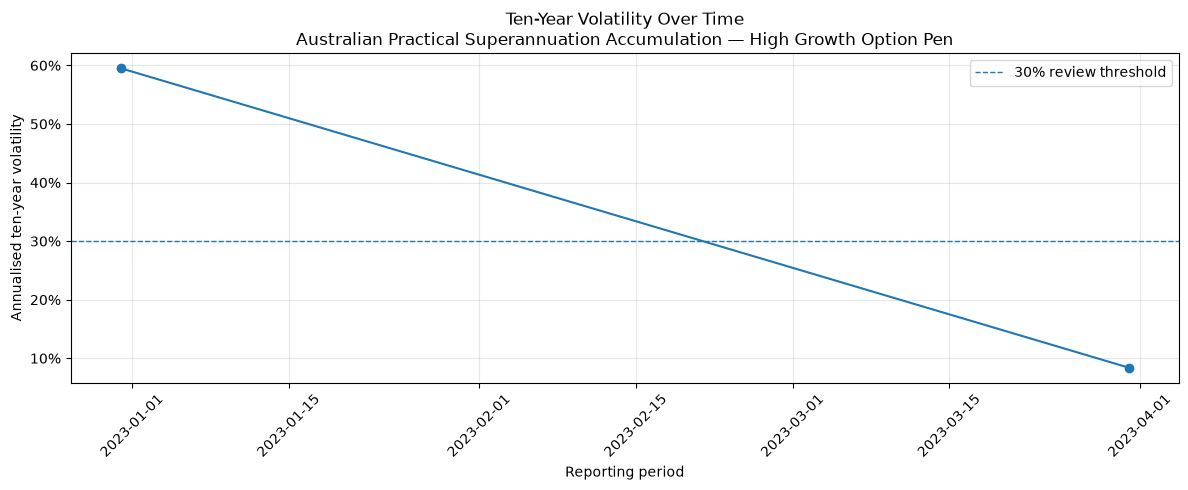

Option identifier: 43905581638-OVPSHGHGRWTH
Maximum volatility: 59.50%



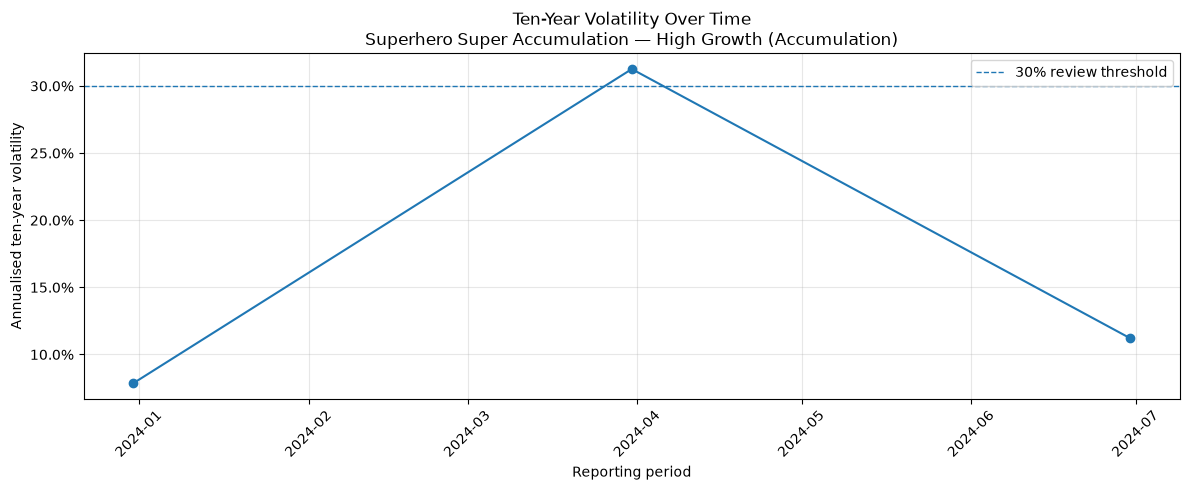

Option identifier: 43905581638-LAMSHGHGRWTH
Maximum volatility: 31.26%



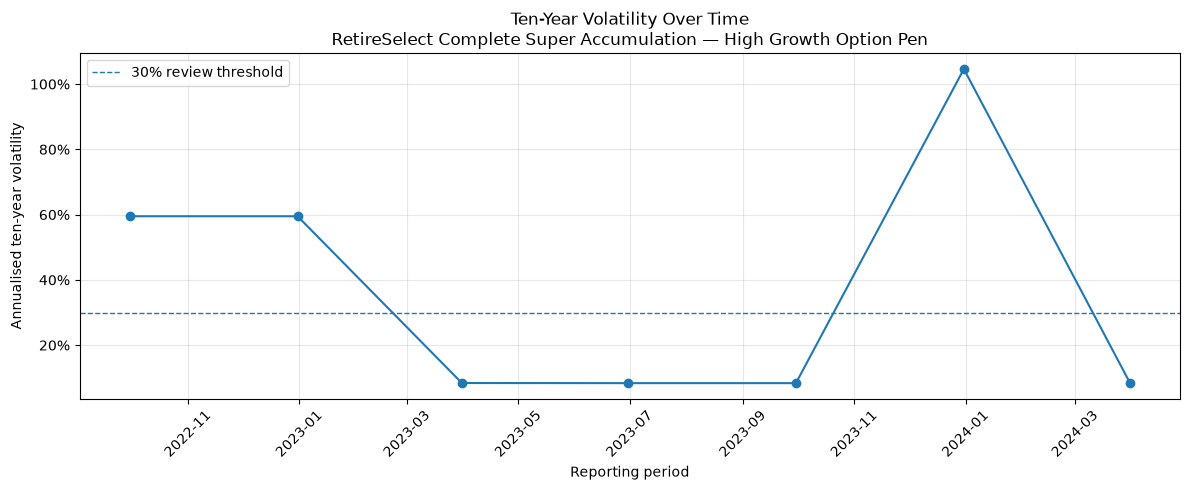

Option identifier: 43905581638-OVPSHGHGRWTH
Maximum volatility: 104.61%



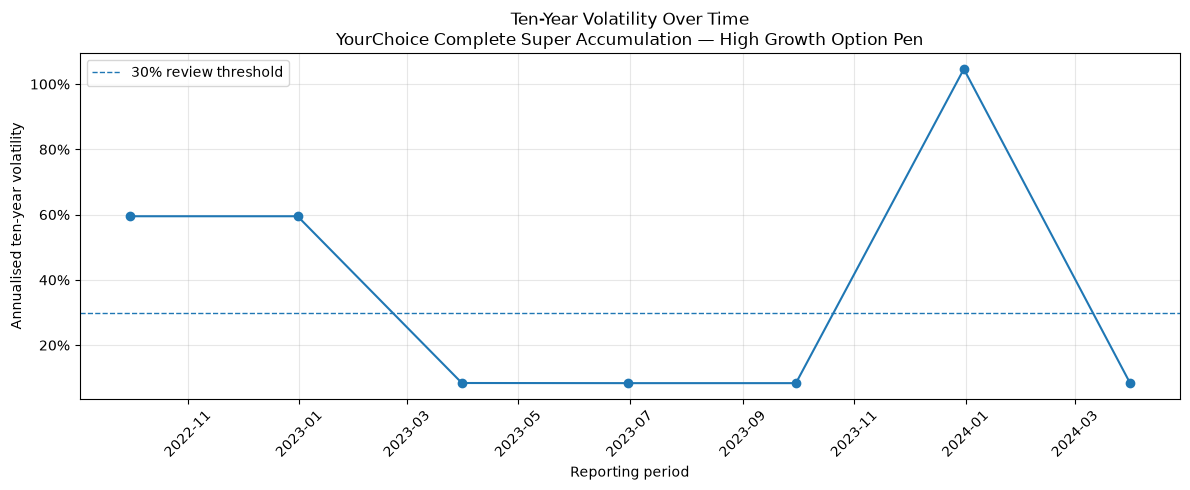

Option identifier: 43905581638-OVPSHGHGRWTH
Maximum volatility: 104.61%



In [95]:
metric_10y = (
    "return_investment_ten_year_"
    "volatility_comparison_percent"
)

option_keys = [
    "rse_abn",
    "abn_product_identifier",
    "abn_investment_menu_identifier",
    "abn_investment_option_identifier",
]

date_col = "period_end_date"
high_threshold = 0.30

hist_enriched[date_col] = pd.to_datetime(
    hist_enriched[date_col],
    errors="coerce"
)

hist_enriched[metric_10y] = pd.to_numeric(
    hist_enriched[metric_10y],
    errors="coerce"
)

hist_enriched[metric_10y] = (
    hist_enriched[metric_10y]
    .replace([np.inf, -np.inf], np.nan)
)

affected_options = (
    hist_enriched.loc[
        hist_enriched[metric_10y].gt(high_threshold),
        option_keys
    ]
    .drop_duplicates()
)

print(
    "Number of affected investment options:",
    len(affected_options)
)

affected_history = hist_enriched.merge(
    affected_options,
    on=option_keys,
    how="inner",
    validate="many_to_many"
)

affected_option_period = (
    affected_history
    .groupby(
        option_keys + [date_col],
        as_index=False,
        dropna=False
    )
    .agg(
        product_name=(
            "product_name",
            "first"
        ),
        investment_option_name=(
            "investment_option_name",
            "first"
        ),
        investment_option_category=(
            "investment_option_category",
            "first"
        ),
        volatility_10y=(
            metric_10y,
            "median"
        ),
        unique_volatility_values=(
            metric_10y,
            "nunique"
        ),
        source_row_count=(
            metric_10y,
            "size"
        ),
    )
    .dropna(
        subset=[date_col, "volatility_10y"]
    )
    .sort_values(
        option_keys + [date_col]
    )
)

conflicting_periods = affected_option_period.loc[
    affected_option_period[
        "unique_volatility_values"
    ].gt(1)
]

print(
    "Option-periods with conflicting volatility values:",
    len(conflicting_periods)
)

for option_values, option_df in affected_option_period.groupby(
    option_keys,
    dropna=False
):
    option_df = option_df.sort_values(date_col)

    product_name = option_df["product_name"].iloc[0]
    option_name = option_df["investment_option_name"].iloc[0]
    option_identifier = option_df[
        "abn_investment_option_identifier"
    ].iloc[0]

    plt.figure(figsize=(12, 5))

    plt.plot(
        option_df[date_col],
        option_df["volatility_10y"],
        marker="o",
        linewidth=1.5
    )

    # Mark the 30% review threshold
    plt.axhline(
        y=high_threshold,
        linestyle="--",
        linewidth=1,
        label="30% review threshold"
    )

    plt.title(
        "Ten-Year Volatility Over Time\n"
        f"{product_name} — {option_name}"
    )

    plt.xlabel("Reporting period")
    plt.ylabel("Annualised ten-year volatility")

    # Raw 0.30 is displayed as 30%
    plt.gca().yaxis.set_major_formatter(
        PercentFormatter(xmax=1)
    )

    plt.grid(alpha=0.3)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print(
        f"Option identifier: {option_identifier}\n"
        f"Maximum volatility: "
        f"{option_df['volatility_10y'].max():.2%}\n"
    )

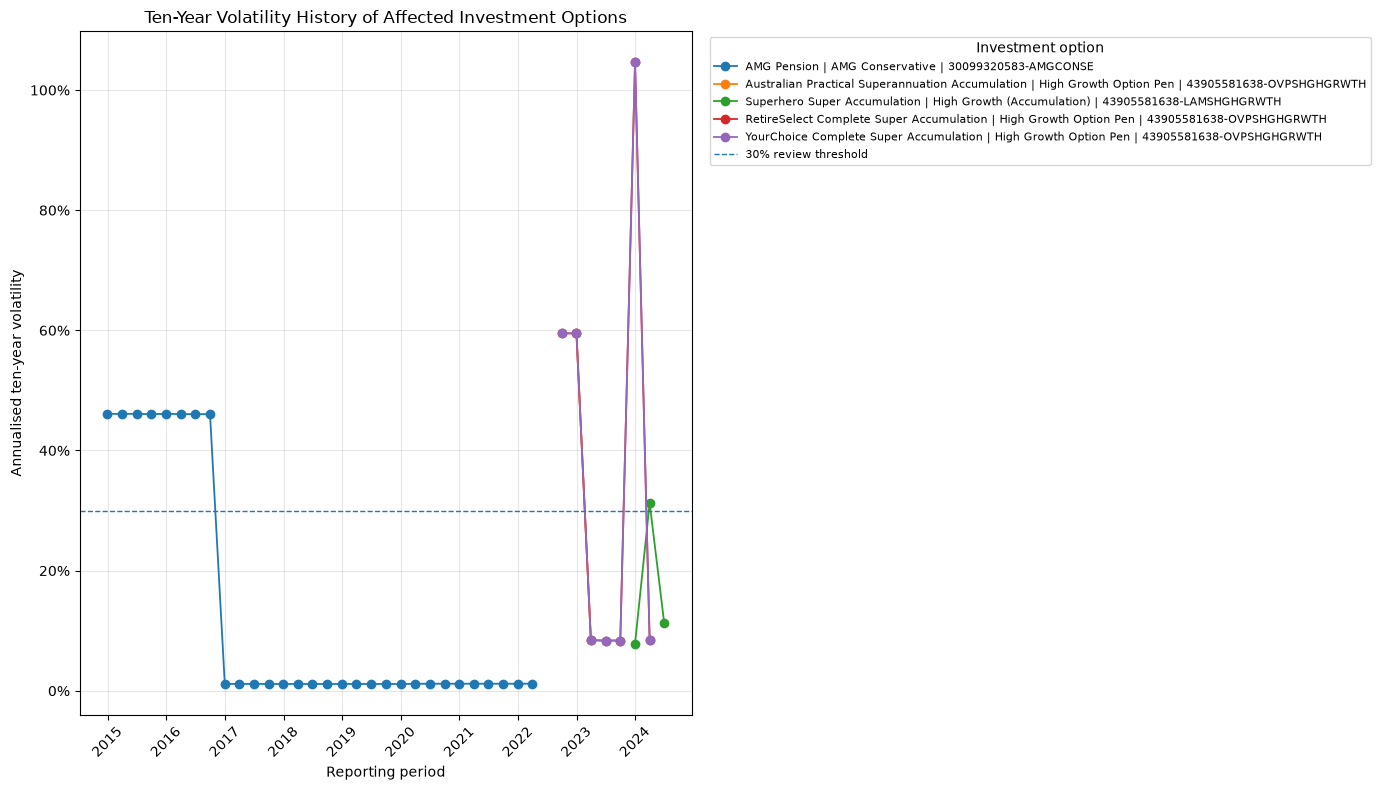

In [96]:
plt.figure(figsize=(14, 8))

for option_values, option_df in affected_option_period.groupby(
    option_keys,
    dropna=False
):
    option_df = option_df.sort_values(date_col)

    product_name = option_df["product_name"].iloc[0]
    option_name = option_df["investment_option_name"].iloc[0]
    option_identifier = option_df[
        "abn_investment_option_identifier"
    ].iloc[0]

    line_label = (
        f"{product_name} | {option_name} | "
        f"{option_identifier}"
    )

    plt.plot(
        option_df[date_col],
        option_df["volatility_10y"],
        marker="o",
        linewidth=1.3,
        label=line_label
    )

plt.axhline(
    y=high_threshold,
    linestyle="--",
    linewidth=1,
    label="30% review threshold"
)

plt.title(
    "Ten-Year Volatility History of Affected Investment Options"
)
plt.xlabel("Reporting period")
plt.ylabel("Annualised ten-year volatility")

plt.gca().yaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)

plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.legend(
    title="Investment option",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()
plt.show()

For each affected options, it happened at specific periods.

In [97]:
hist_enriched[f"{metric_10y}_raw"] = (
    hist_enriched[metric_10y]
)

hist_enriched[f"{metric_10y}_clean"] = (
    hist_enriched[metric_10y]
)

hist_enriched[
    "volatility_10y_quality_status"
] = "reported"

hist_enriched[
    "volatility_10y_high_flag"
] = (
    hist_enriched[metric_10y].gt(0.30)
)

### Checking historical SAA file

In [98]:
historical_saa.info()

<class 'pandas.DataFrame'>
RangeIndex: 426917 entries, 0 to 426916
Data columns (total 23 columns):
 #   Column                                                Non-Null Count   Dtype  
---  ------                                                --------------   -----  
 0   investment_option_identifier                          426917 non-null  str    
 1   time_key                                              426917 non-null  int64  
 2   investment_option_name                                426917 non-null  str    
 3   investment_option_type                                426917 non-null  str    
 4   investment_option_category                            426917 non-null  str    
 5   rse_name                                              426917 non-null  str    
 6   rse_abn                                               426917 non-null  int64  
 7   rsl_name                                              426917 non-null  str    
 8   Public_Offer_Status                                   4

In [99]:
historical_saa.head()

,investment_option_identifier,time_key,investment_option_name,investment_option_type,investment_option_category,rse_name,rse_abn,rsl_name,Public_Offer_Status,ConsolidatedSectorType,...,InvestmentStrategicSectorType,InvestmentStrategicSectorListingType,InvestmentStrategicSectorDomicileType,InvestmentStrategicSectorInternationalEconomyType,InvestmentStrategicSubsectorType,InvestmentStrategicSubsectorListingType,InvestmentStrategicSubsectorDomicileType,InvestmentStrategicSubsectorInternationalEconomyType,InvestmentBenchmarkAllocationPercent,InvestmentCurrencyHedgingRatioPercent
0,83810127567-AZ49C1MySuper,20140630,Balanced Growth MySuper,Multi Manager,Multi Sector,ANZ Australian Staff Superannuation Scheme,83810127567,ANZ Staff Superannuation (Australia) Pty. Limited,Non-public offer,Fixed Income,...,Fixed Income,Not Applicable,Australian Domicile,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,0.09,0.0
1,83810127567-AZ49C1MySuper,20140630,Balanced Growth MySuper,Multi Manager,Multi Sector,ANZ Australian Staff Superannuation Scheme,83810127567,ANZ Staff Superannuation (Australia) Pty. Limited,Non-public offer,Credit,...,Credit,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,0.03,1.0
2,83810127567-AZ49C1MySuper,20140630,Balanced Growth MySuper,Multi Manager,Multi Sector,ANZ Australian Staff Superannuation Scheme,83810127567,ANZ Staff Superannuation (Australia) Pty. Limited,Non-public offer,Infrastructure,...,Infrastructure,Unlisted,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,0.06,0.0
3,83810127567-AZ49C1MySuper,20140630,Balanced Growth MySuper,Multi Manager,Multi Sector,ANZ Australian Staff Superannuation Scheme,83810127567,ANZ Staff Superannuation (Australia) Pty. Limited,Non-public offer,Alternatives,...,Alternatives,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,0.08,1.0
4,83810127567-AZ49C1MySuper,20140630,Balanced Growth MySuper,Multi Manager,Multi Sector,ANZ Australian Staff Superannuation Scheme,83810127567,ANZ Staff Superannuation (Australia) Pty. Limited,Non-public offer,Cash,...,Cash,Not Applicable,Australian Domicile,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,0.03,0.0


#### Convert time key to date data type

In [100]:
historical_saa["time_key"].unique()

array([20140630, 20140930, 20141231, 20150331, 20150630, 20150930,
       20151231, 20160331, 20160630, 20160930, 20161231, 20170331,
       20170630, 20170930, 20171231, 20180331, 20180630, 20180930,
       20181231, 20190331, 20190630, 20190930, 20191231, 20200331,
       20200630, 20200930, 20201231, 20210331, 20210630, 20210930,
       20211231, 20220331, 20220630, 20220930, 20221231, 20230331,
       20230630, 20230930, 20231231, 20240331, 20240630, 20240930,
       20241231, 20250331, 20250630, 20250930, 20251231, 20260331])

In [101]:
historical_saa["time_key"] = pd.to_datetime(
    historical_saa["time_key"]
        .astype("Int64")
        .astype("string"),
    format="%Y%m%d",
    errors="coerce"
)

In [115]:
historical_saa[["time_key"]].head()
historical_saa["time_key"].dtype

dtype('<M8[us]')

#### Checking InvestmentCurrencyHedgingRatioPercent column

In [109]:
historical_saa["InvestmentCurrencyHedgingRatioPercent"].describe()

count    426917.000000
mean          0.319534
std           0.446104
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           1.000000
Name: InvestmentCurrencyHedgingRatioPercent, dtype: float64

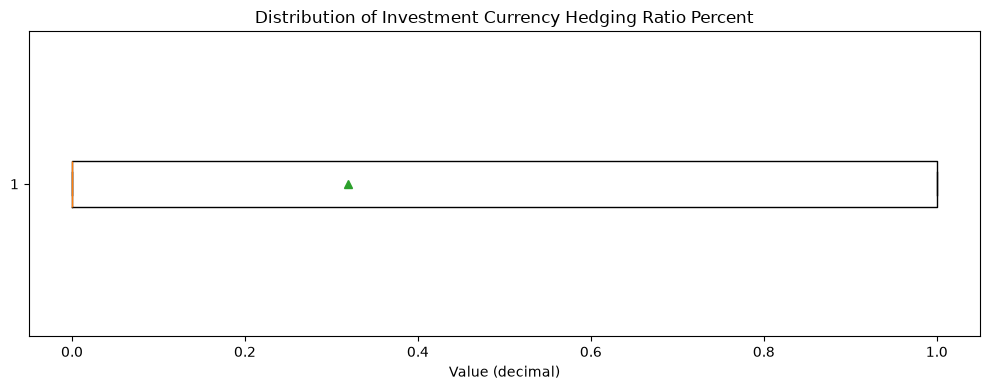

In [110]:
saa_hedgingRatioPercent = historical_saa["InvestmentCurrencyHedgingRatioPercent"]

# Create boxplot
plt.figure(figsize=(10, 4))
plt.boxplot(
    saa_hedgingRatioPercent,
    orientation="horizontal",
    showmeans=True
)

plt.title(f"Distribution of Investment Currency Hedging Ratio Percent")
plt.xlabel("Value (decimal)")
# plt.yticks([1], [metric])
plt.tight_layout()
plt.show()

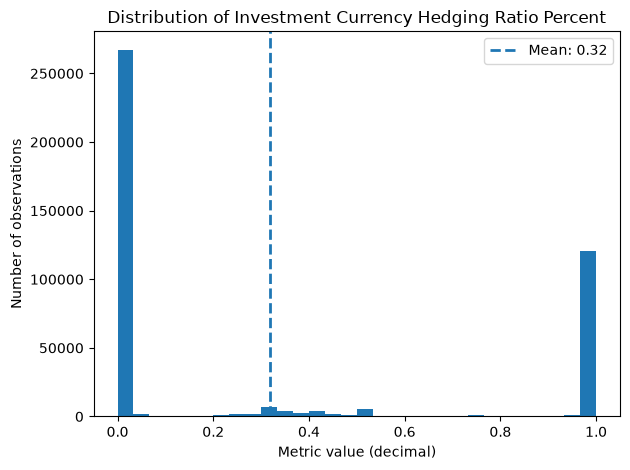

In [111]:
plt.hist(saa_hedgingRatioPercent, bins=30)
plt.axvline(
    saa_hedgingRatioPercent.mean(),
    linestyle = "--",
    linewidth = 2,
    label=f"Mean: {saa_hedgingRatioPercent.mean():.2f}")


plt.title(f"Distribution of Investment Currency Hedging Ratio Percent")
plt.xlabel("Metric value (decimal)")
plt.ylabel("Number of observations")
plt.legend()
plt.tight_layout()
plt.show()

At first glance, there is no "outlier". But the distribution is abnormal as there are extreme difference of each end of the values. This should be checked further.

In [112]:
saa_hedgingRatioPercent.median()

np.float64(0.0)

APRA defines the metric as the target level of currency hedging adopted for the investment strategy. APRA’s reporting instructions also explicitly recognise fully hedged positions as 100%, and generally apply the ratio to internationally domiciled—or certain not-specified-domicile—allocations.

Issue 1 that could be addressed: whether the row represents an allocation for which currency hedging is applicable.

Under current APRA instructions, currency hedging ratios are primarily reported for internationally domiciled allocations and certain allocations with domicile recorded as not specified.

In [117]:
saa = historical_saa.copy()

metric = "InvestmentCurrencyHedgingRatioPercent"
allocation = "InvestmentBenchmarkAllocationPercent"

saa["ConsolidatedDomicileType"].value_counts(
    dropna=False
)

ConsolidatedDomicileType
International Domicile    198228
Australian Domicile       156924
Not Specified              52704
Not Applicable             19061
Name: count, dtype: int64

In [119]:
tolerance = 1e-10

is_zero = np.isclose(
    saa[metric],
    0,
    atol=tolerance
)

is_one = np.isclose(
    saa[metric],
    1,
    atol=tolerance
)

is_partial = (
    saa[metric].gt(0)
    & saa[metric].lt(1)
)

saa["hedging_ratio_category"] = np.select(
    [
        saa[metric].isna(),
        saa[metric].lt(0),
        saa[metric].gt(1),
        is_zero,
        is_one,
        is_partial,
    ],
    [
        "Missing",
        "Invalid: below 0",
        "Invalid: above 1",
        "Unhedged: 0%",
        "Fully hedged: 100%",
        "Partially hedged",
    ],
    default="Unclassified"
)

domicile_hedging_table = pd.crosstab(
    saa["ConsolidatedDomicileType"],
    saa["hedging_ratio_category"],
    margins=True
)

domicile_hedging_table

hedging_ratio_category,Fully hedged: 100%,Partially hedged,Unhedged: 0%,All
ConsolidatedDomicileType,,,,
Australian Domicile,1202,203,155519,156924
International Domicile,97444,36904,63880,198228
Not Applicable,2234,1171,15656,19061
Not Specified,19691,3078,29935,52704
All,120571,41356,264990,426917


In [120]:
domicile_hedging_percent = pd.crosstab(
    saa["ConsolidatedDomicileType"],
    saa["hedging_ratio_category"],
    normalize="index"
) * 100

domicile_hedging_percent.round(2)

hedging_ratio_category,Fully hedged: 100%,Partially hedged,Unhedged: 0%
ConsolidatedDomicileType,,,
Australian Domicile,0.77,0.13,99.10
International Domicile,49.16,18.62,32.23
Not Applicable,11.72,6.14,82.14
Not Specified,37.36,5.84,56.80


In [121]:
domicile_normalised = (
    saa["ConsolidatedDomicileType"]
    .astype("string")
    .str.strip()
    .str.casefold()
)

saa["hedging_ratio_applicable"] = (
    domicile_normalised.str.contains(
        r"international|not specified",
        regex=True,
        na=False
    )
)

applicable_distribution = (
    saa.loc[
        saa["hedging_ratio_applicable"],
        "hedging_ratio_category"
    ]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="number_rows")
)

applicable_distribution

,category,number_rows
0,Fully hedged: 100%,117135
1,Unhedged: 0%,93815
2,Partially hedged,39982


Exclude zero-allocation SAA rows from hedging analysis because an SAA row with zero benchmark allocation should not influence an option-level hedging calculation.

In [122]:
hedging_analysis_rows = saa.loc[
    saa["hedging_ratio_applicable"]
    & saa[allocation].gt(0)
    & saa[metric].between(0, 1)
].copy()

print(
    "Applicable positive-allocation rows:",
    len(hedging_analysis_rows)
)

Applicable positive-allocation rows: 207108


Check whether the ratio is repeated across rows, One option-period can have multiple sectors and subsectors.

In [125]:
option_period_keys = [
    "rse_abn",
    "investment_option_identifier",
    "time_key",
]

option_period_diagnosis = (
    hedging_analysis_rows
    .groupby(
        option_period_keys,
        as_index=False,
        dropna=False
    )
    .agg(
        number_saa_rows=(metric, "size"),
        distinct_hedging_ratios=(metric, "nunique"),
        minimum_hedging_ratio=(metric, "min"),
        maximum_hedging_ratio=(metric, "max"),
        total_benchmark_allocation=(allocation, "sum"),
    )
)

option_period_diagnosis[
    "distinct_hedging_ratios"
].value_counts().sort_index()



distinct_hedging_ratios
1     8218
2    14456
3    15451
4     1799
5      560
6      305
7       19
8        8
9        1
Name: count, dtype: int64

In [127]:
hedging_analysis_rows["hedging_ratio_rounded"] = (
    hedging_analysis_rows[
        "InvestmentCurrencyHedgingRatioPercent"
    ]
    .round(6)
)

option_period_diagnosis = (
    hedging_analysis_rows
    .groupby(
        option_period_keys,
        as_index=False,
        dropna=False
    )
    .agg(
        number_saa_rows=(
            "hedging_ratio_rounded",
            "size"
        ),
        distinct_hedging_ratios=(
            "hedging_ratio_rounded",
            "nunique"
        ),
        minimum_hedging_ratio=(
            "hedging_ratio_rounded",
            "min"
        ),
        maximum_hedging_ratio=(
            "hedging_ratio_rounded",
            "max"
        ),
        total_benchmark_allocation=(
            "InvestmentBenchmarkAllocationPercent",
            "sum"
        ),
    )
)

Approximately 73% of the option-periods contain either two or three different hedging ratios. Because of that, we should not select the first value or calculate an unweighted average but calculate the benchmark-allocation-weighted hedging ratio.

In [128]:
hedging_analysis_rows["weighted_component"] = (
    hedging_analysis_rows[
        "InvestmentCurrencyHedgingRatioPercent"
    ]
    * hedging_analysis_rows[
        "InvestmentBenchmarkAllocationPercent"
    ]
)

option_period_hedging = (
    hedging_analysis_rows
    .groupby(
        option_period_keys,
        as_index=False
    )
    .agg(
        weighted_numerator=(
            "weighted_component",
            "sum"
        ),
        applicable_allocation=(
            "InvestmentBenchmarkAllocationPercent",
            "sum"
        ),
        distinct_hedging_ratios=(
            "hedging_ratio_rounded",
            "nunique"
        ),
    )
)

option_period_hedging[
    "weighted_currency_hedging_ratio"
] = (
    option_period_hedging["weighted_numerator"]
    / option_period_hedging["applicable_allocation"]
)

#### Checking InvestmentBenchmarkAllocationPercent column